# Radar DSP Pipeline Walkthrough

This notebook is a reproducible walkthrough of the `radar-dsp-pipeline` repository.

The pipeline demonstrates how basic DSP decisions affect radar-relevant detection behavior:

1. A signal can be buried in noise.
2. FFT processing can expose a spectral/Doppler peak.
3. Peak visibility must be measured against a noise floor.
4. Filtering changes spectral content and detectability.
5. Windowing changes leakage, coherent gain, and equivalent noise bandwidth.
6. Doppler-like detection requires thresholding and empirical Pd/Pfa estimation.
7. System-level DSP choices produce measurable Pd/Pfa/SNR trade-offs.

The notebook does not duplicate the implementation logic.  
The implementation lives in `src/`; the executable stages live in `scripts/`.

This notebook orchestrates the stages, verifies generated artifacts, and provides a readable engineering narrative.

## 0. Repository setup

This cell resolves the repository root, configures imports, and verifies the expected project structure.

In [1]:
from __future__ import annotations

import os
import sys
import subprocess
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

# Resolve repository root from the notebook location.
# Expected notebook path:
#   radar-dsp-pipeline/notebooks/radar_dsp_pipeline_walkthrough.ipynb
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXPECTED_PATHS = [
    REPO_ROOT / "src" / "signals.py",
    REPO_ROOT / "src" / "fft_tools.py",
    REPO_ROOT / "src" / "filters.py",
    REPO_ROOT / "src" / "windows.py",
    REPO_ROOT / "src" / "detection.py",
    REPO_ROOT / "scripts" / "01_signals_noise_fft.py",
    REPO_ROOT / "scripts" / "02_fir_iir_filters.py",
    REPO_ROOT / "scripts" / "03_windowing_leakage.py",
    REPO_ROOT / "scripts" / "04_detection_doppler.py",
    REPO_ROOT / "scripts" / "05_system_tradeoffs.py",
]

missing = [p for p in EXPECTED_PATHS if not p.exists()]
if missing:
    raise FileNotFoundError("Missing expected repository files:\n" + "\n".join(str(p) for p in missing))

FIGURES_DIR = REPO_ROOT / "figures" / "generated_plots"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[OK] Repository root: {REPO_ROOT}")
print(f"[OK] Figures directory: {FIGURES_DIR.relative_to(REPO_ROOT)}")

[OK] Repository root: /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline
[OK] Figures directory: figures/generated_plots


## 1. Utility functions

The notebook runs scripts exactly as pipeline stages.  
Each stage is executed from the repository root, so all paths remain repo-relative and reproducible.

In [2]:
def run_stage(script_name: str, *args: str) -> None:
    """
    Run a pipeline stage from the repository root.

    Parameters
    ----------
    script_name:
        Filename inside the scripts/ directory.
    *args:
        Optional command-line arguments passed to the script.
    """
    script_path = REPO_ROOT / "scripts" / script_name
    cmd = [sys.executable, str(script_path), *args]

    print("[RUN]", " ".join(cmd))

    completed = subprocess.run(
        cmd,
        cwd=REPO_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )

    print(completed.stdout)

    if completed.returncode != 0:
        raise RuntimeError(f"Stage failed with exit code {completed.returncode}: {script_name}")


def show_artifact(relative_path: str, width: int = 950) -> None:
    """
    Display a generated image artifact from the repository.

    Parameters
    ----------
    relative_path:
        Repository-relative artifact path.
    width:
        Display width in pixels.
    """
    path = REPO_ROOT / relative_path
    if not path.exists():
        raise FileNotFoundError(path)

    print(f"[ARTIFACT] {relative_path}")
    display(Image(filename=str(path), width=width))


def read_csv_artifact(relative_path: str) -> pd.DataFrame:
    """
    Load a generated CSV artifact from the repository.
    """
    path = REPO_ROOT / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

## 2. Stage 01 — Signal buried in noise, FFT visibility, and detectability

Stage 01 demonstrates the first radar-DSP idea: a weak sinusoidal component may be hard to see in time domain, but a narrowband peak can emerge in the frequency domain.

The script generates several SNR cases, computes the FFT, detects the spectral peak, estimates the noise floor, and reports peak-to-noise-floor detectability.

[RUN] /Users/jpsmac/tmp/radar_clone_test/.venv/bin/python /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline/scripts/01_signals_noise_fft.py
SNR= -20.00 dB | Peak=    0.99 dB @    50.00 Hz | Floor=   -8.55 dB | Detectability=    9.54 dB
SNR= -10.00 dB | Peak=    0.08 dB @    50.00 Hz | Floor=  -18.90 dB | Detectability=   18.98 dB
SNR=   0.00 dB | Peak=   -0.05 dB @    50.00 Hz | Floor=  -28.84 dB | Detectability=   28.79 dB
SNR=  10.00 dB | Peak=    0.01 dB @    50.00 Hz | Floor=  -38.05 dB | Detectability=   38.06 dB

[OK] Generated Stage 01 artifacts:
  figures/generated_plots/01_multi_snr_spectrum.png
  figures/generated_plots/01_detectability_vs_snr.png

[ARTIFACT] figures/generated_plots/01_multi_snr_spectrum.png


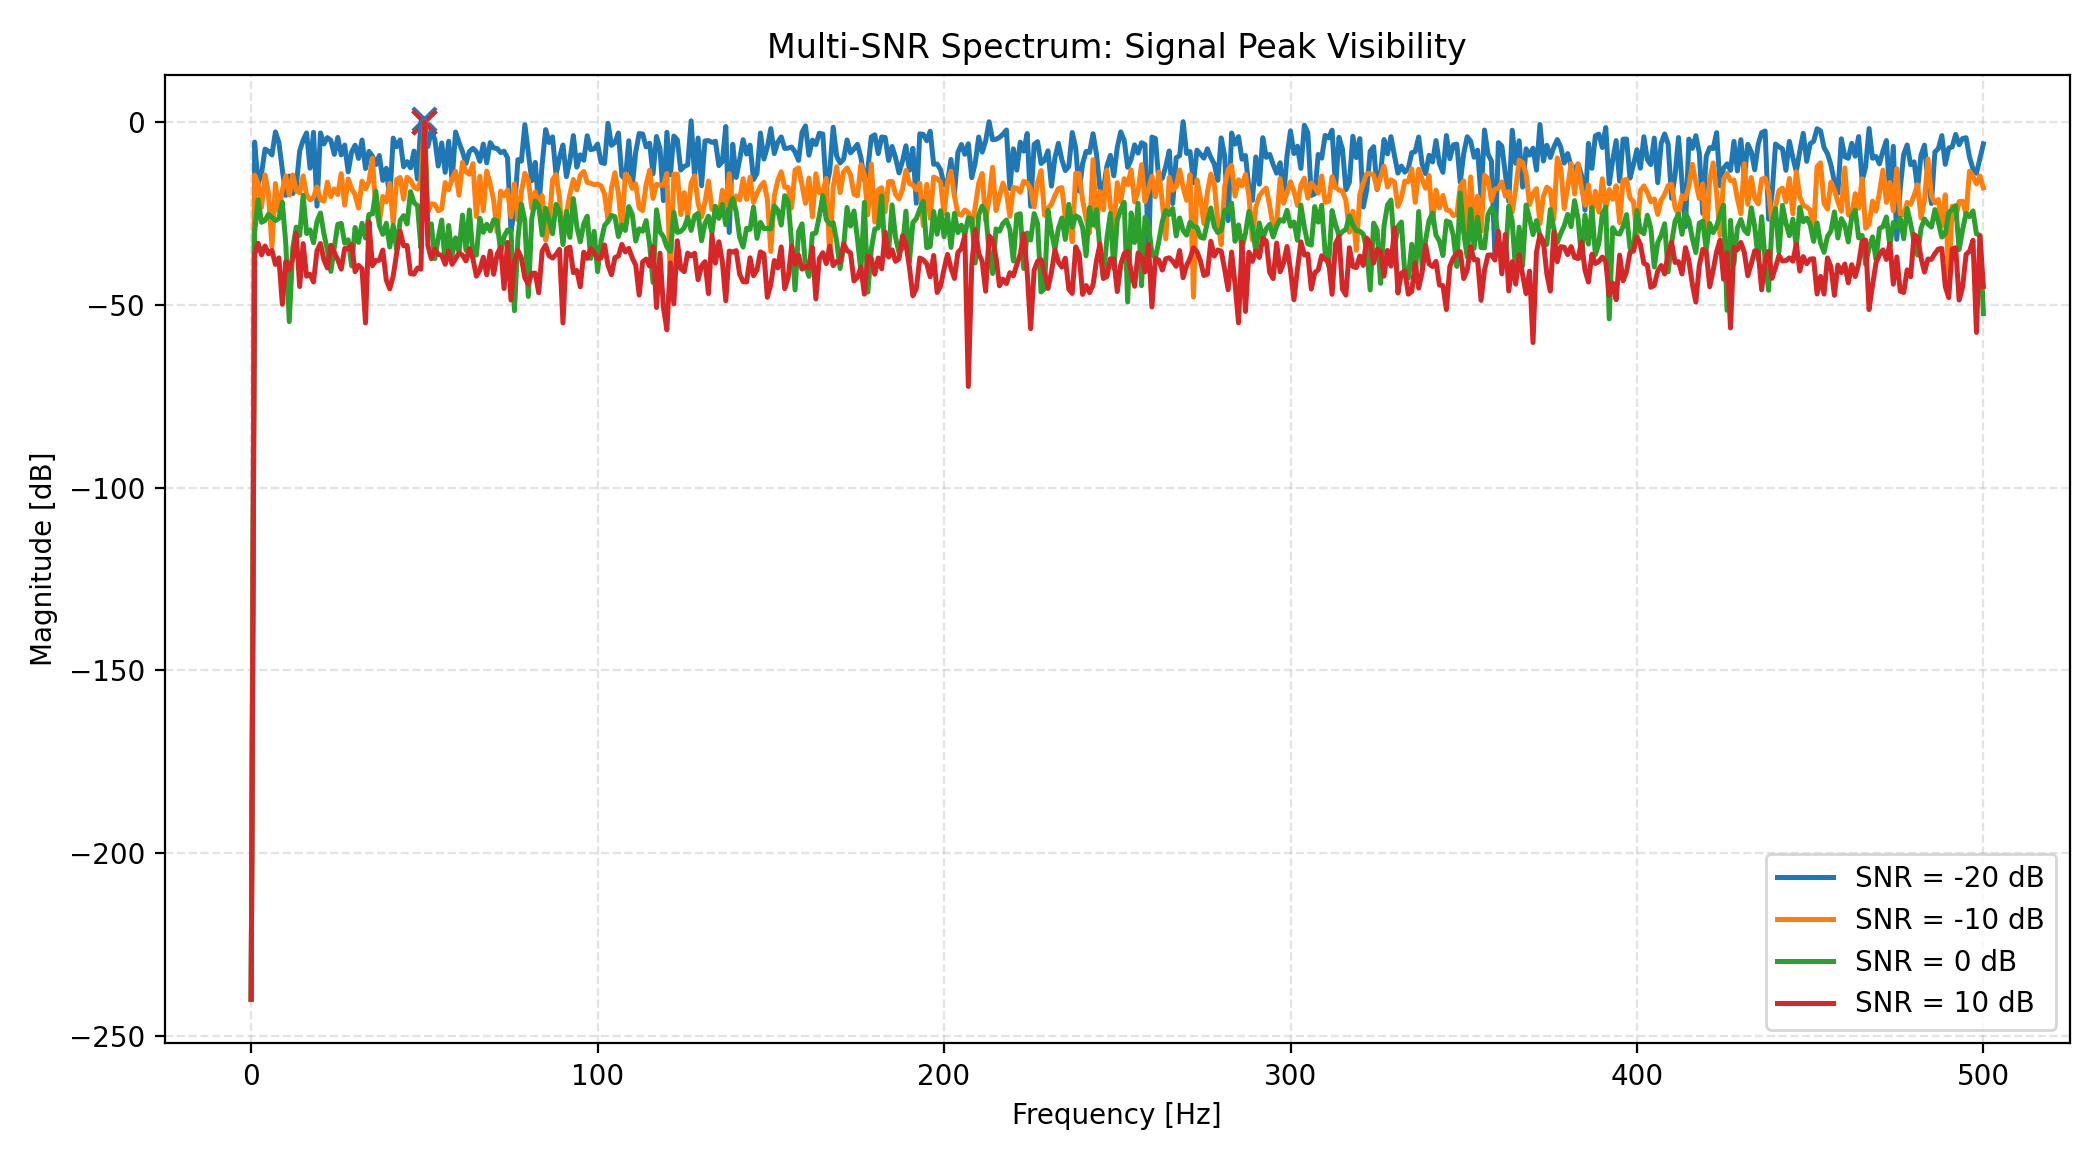

[ARTIFACT] figures/generated_plots/01_detectability_vs_snr.png


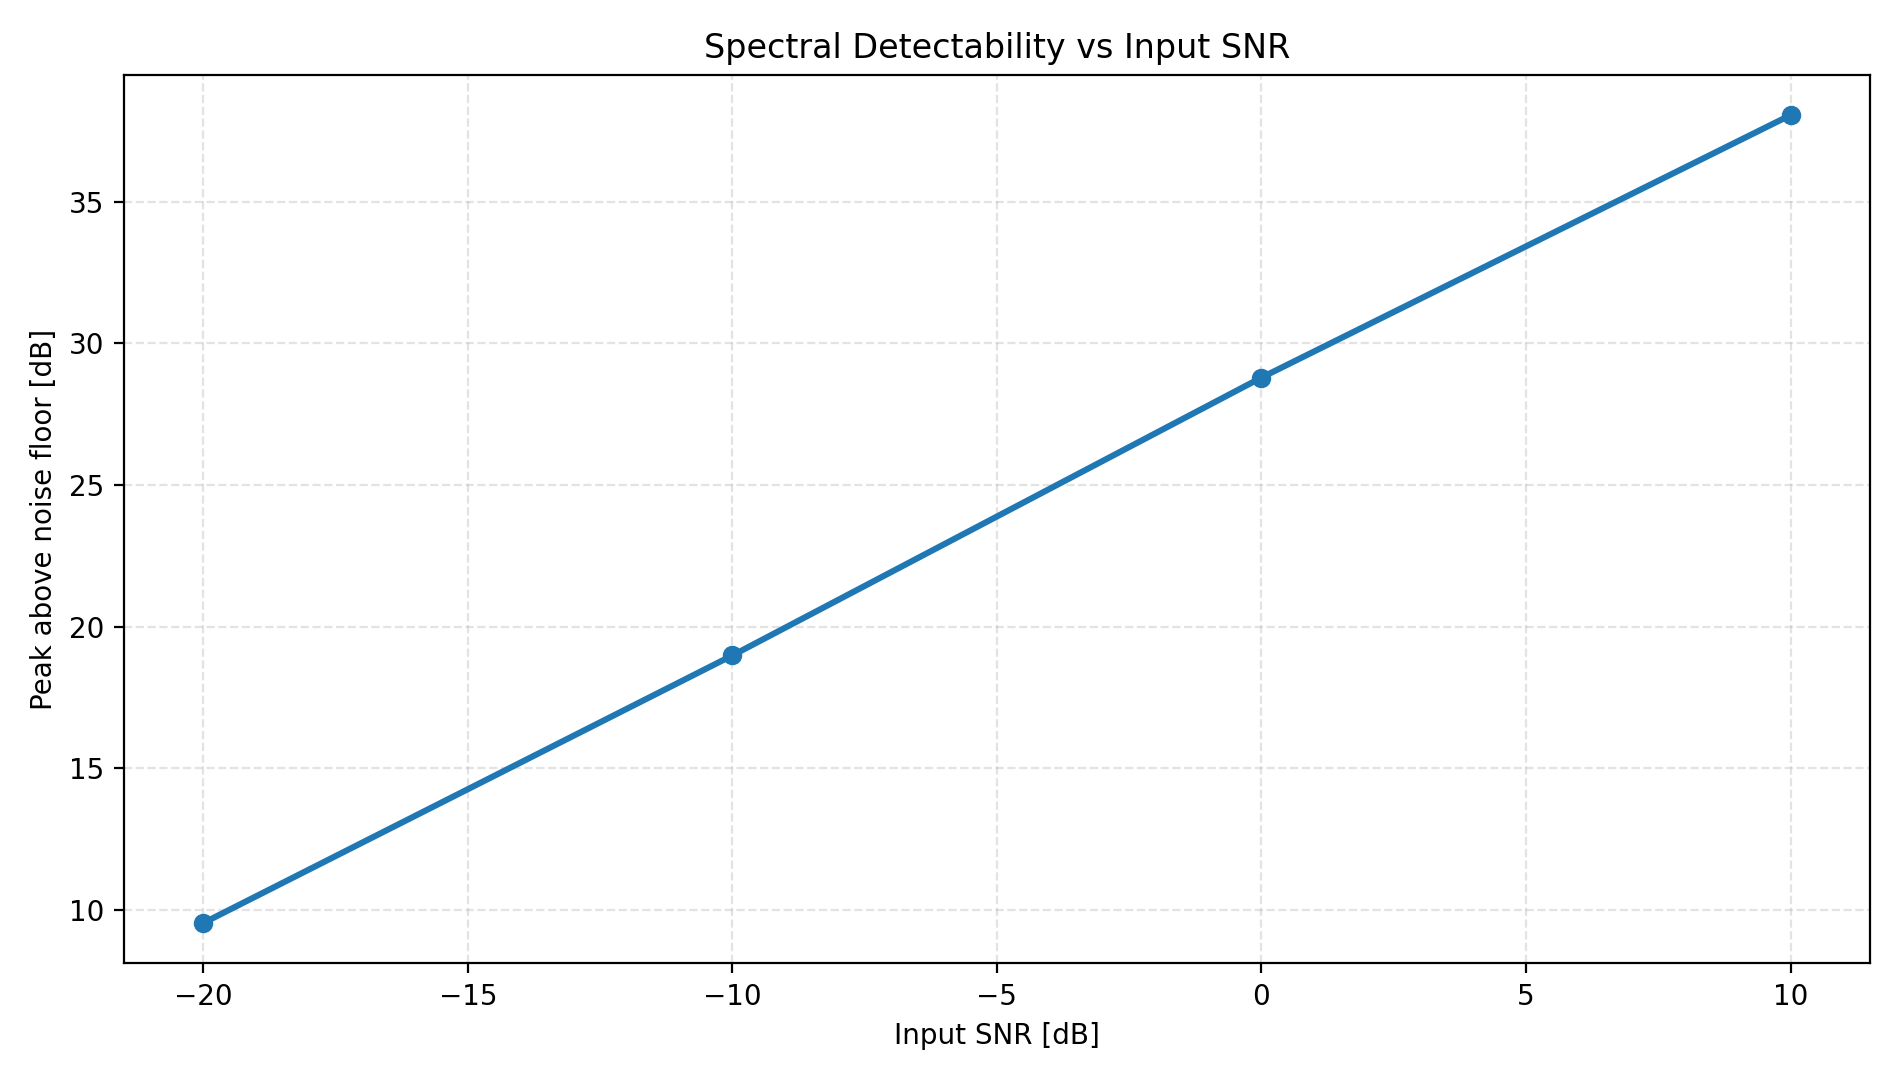

In [3]:
run_stage("01_signals_noise_fft.py")

show_artifact("figures/generated_plots/01_multi_snr_spectrum.png")
show_artifact("figures/generated_plots/01_detectability_vs_snr.png")

## 3. Stage 02 — FIR/IIR filtering and detectability

Stage 02 compares low-pass FIR and IIR filters.

The point is not that filtering is automatically good. The point is that filter design changes spectral content, noise bandwidth, and therefore the measured visibility of a signal component.

[RUN] /Users/jpsmac/tmp/radar_clone_test/.venv/bin/python /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline/scripts/02_fir_iir_filters.py

[OK] Stage 02 detectability summary
Unfiltered     | Peak=    0.31 dB @    50.00 Hz | Floor=  -18.55 dB | Detectability=   18.87 dB
FIR low-pass   | Peak=   -0.17 dB @    50.00 Hz | Floor=  -59.35 dB | Detectability=   59.18 dB
IIR low-pass   | Peak=    0.25 dB @    50.00 Hz | Floor=  -48.84 dB | Detectability=   49.09 dB

[OK] Generated Stage 02 artifacts:
  figures/generated_plots/02_filter_response_fir_vs_iir.png
  figures/generated_plots/02_filtered_signal_spectrum.png
  figures/generated_plots/02_filter_detectability_summary.png

[ARTIFACT] figures/generated_plots/02_filter_response_fir_vs_iir.png


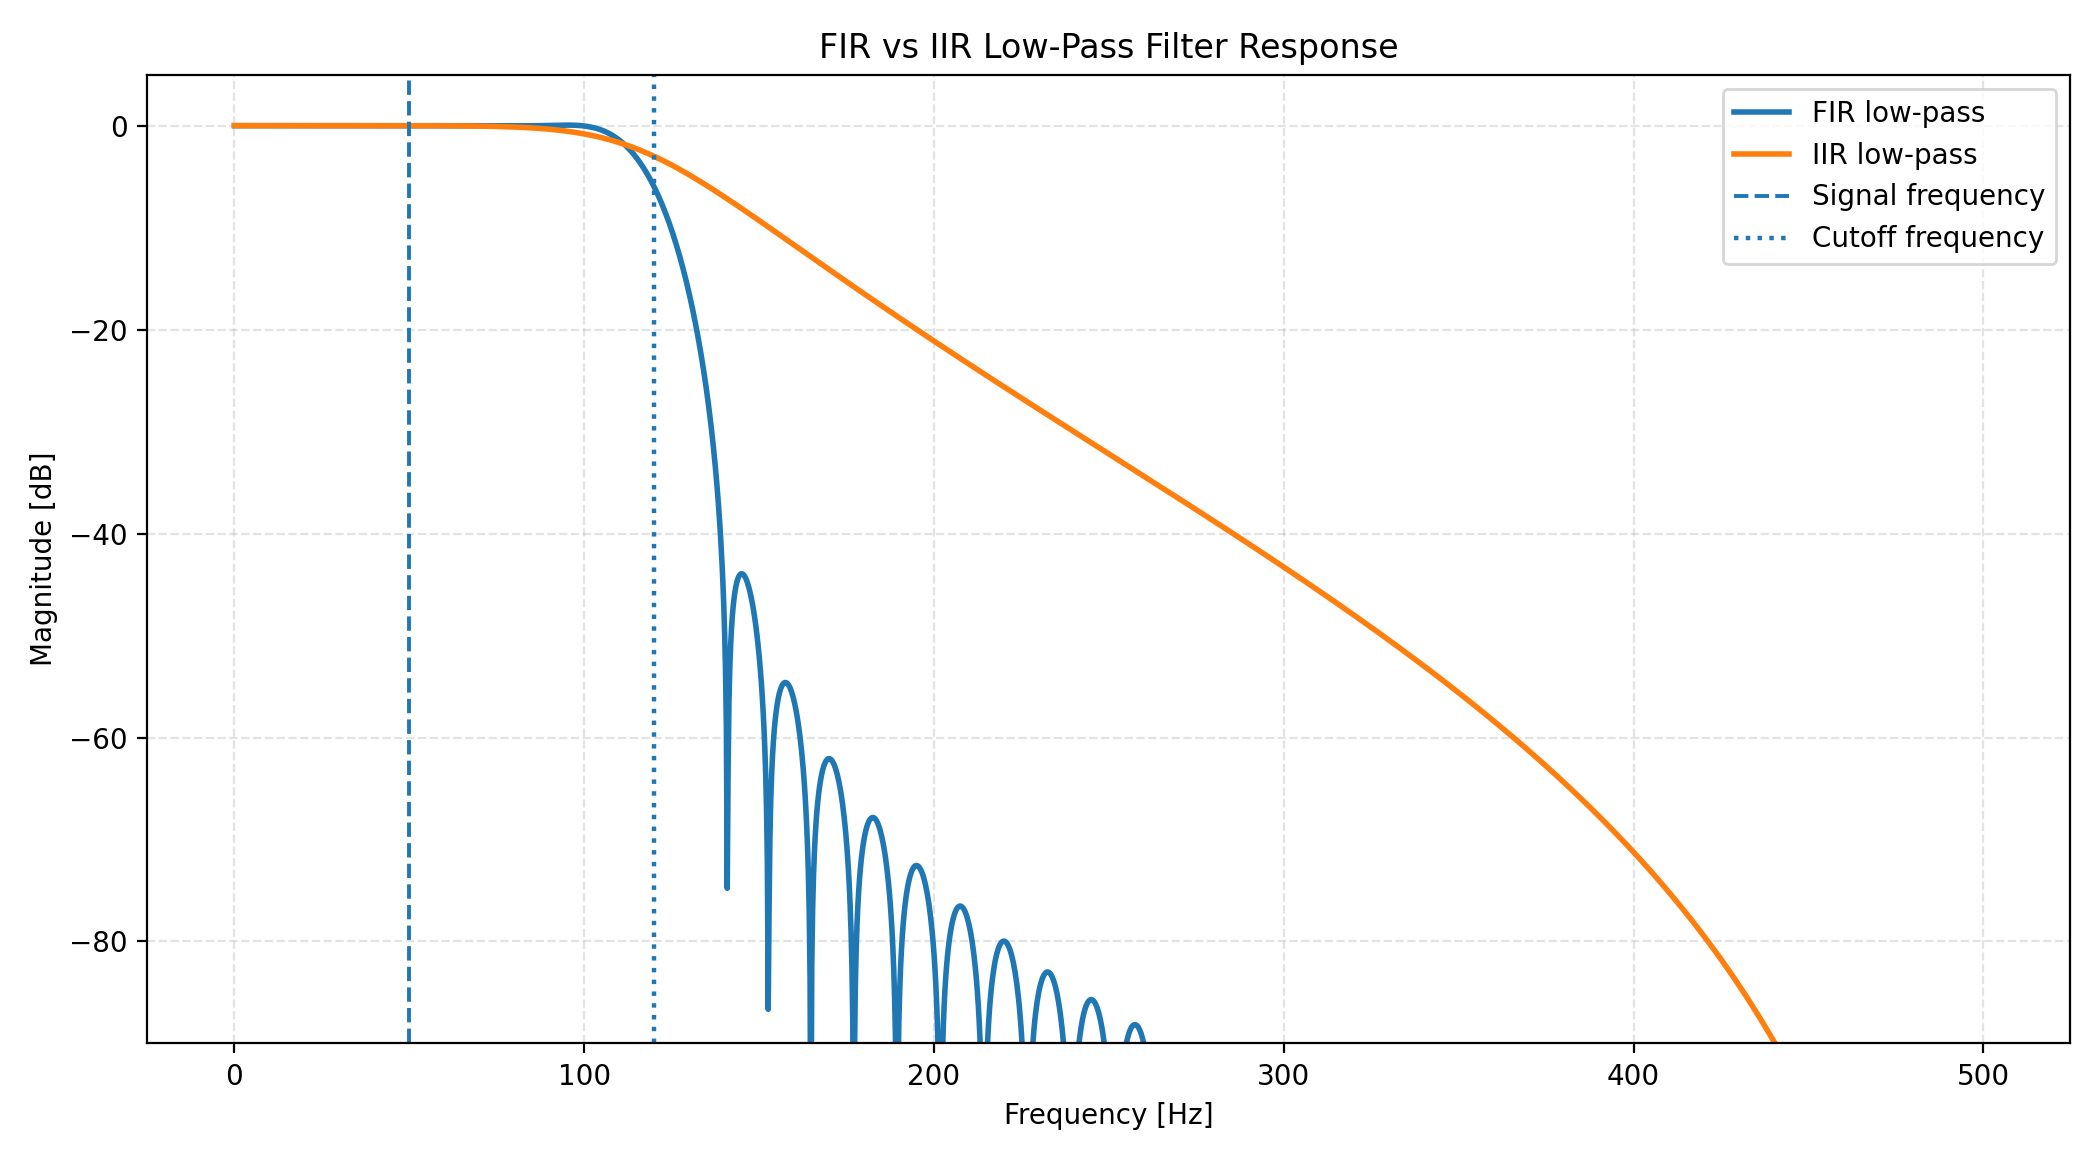

[ARTIFACT] figures/generated_plots/02_filtered_signal_spectrum.png


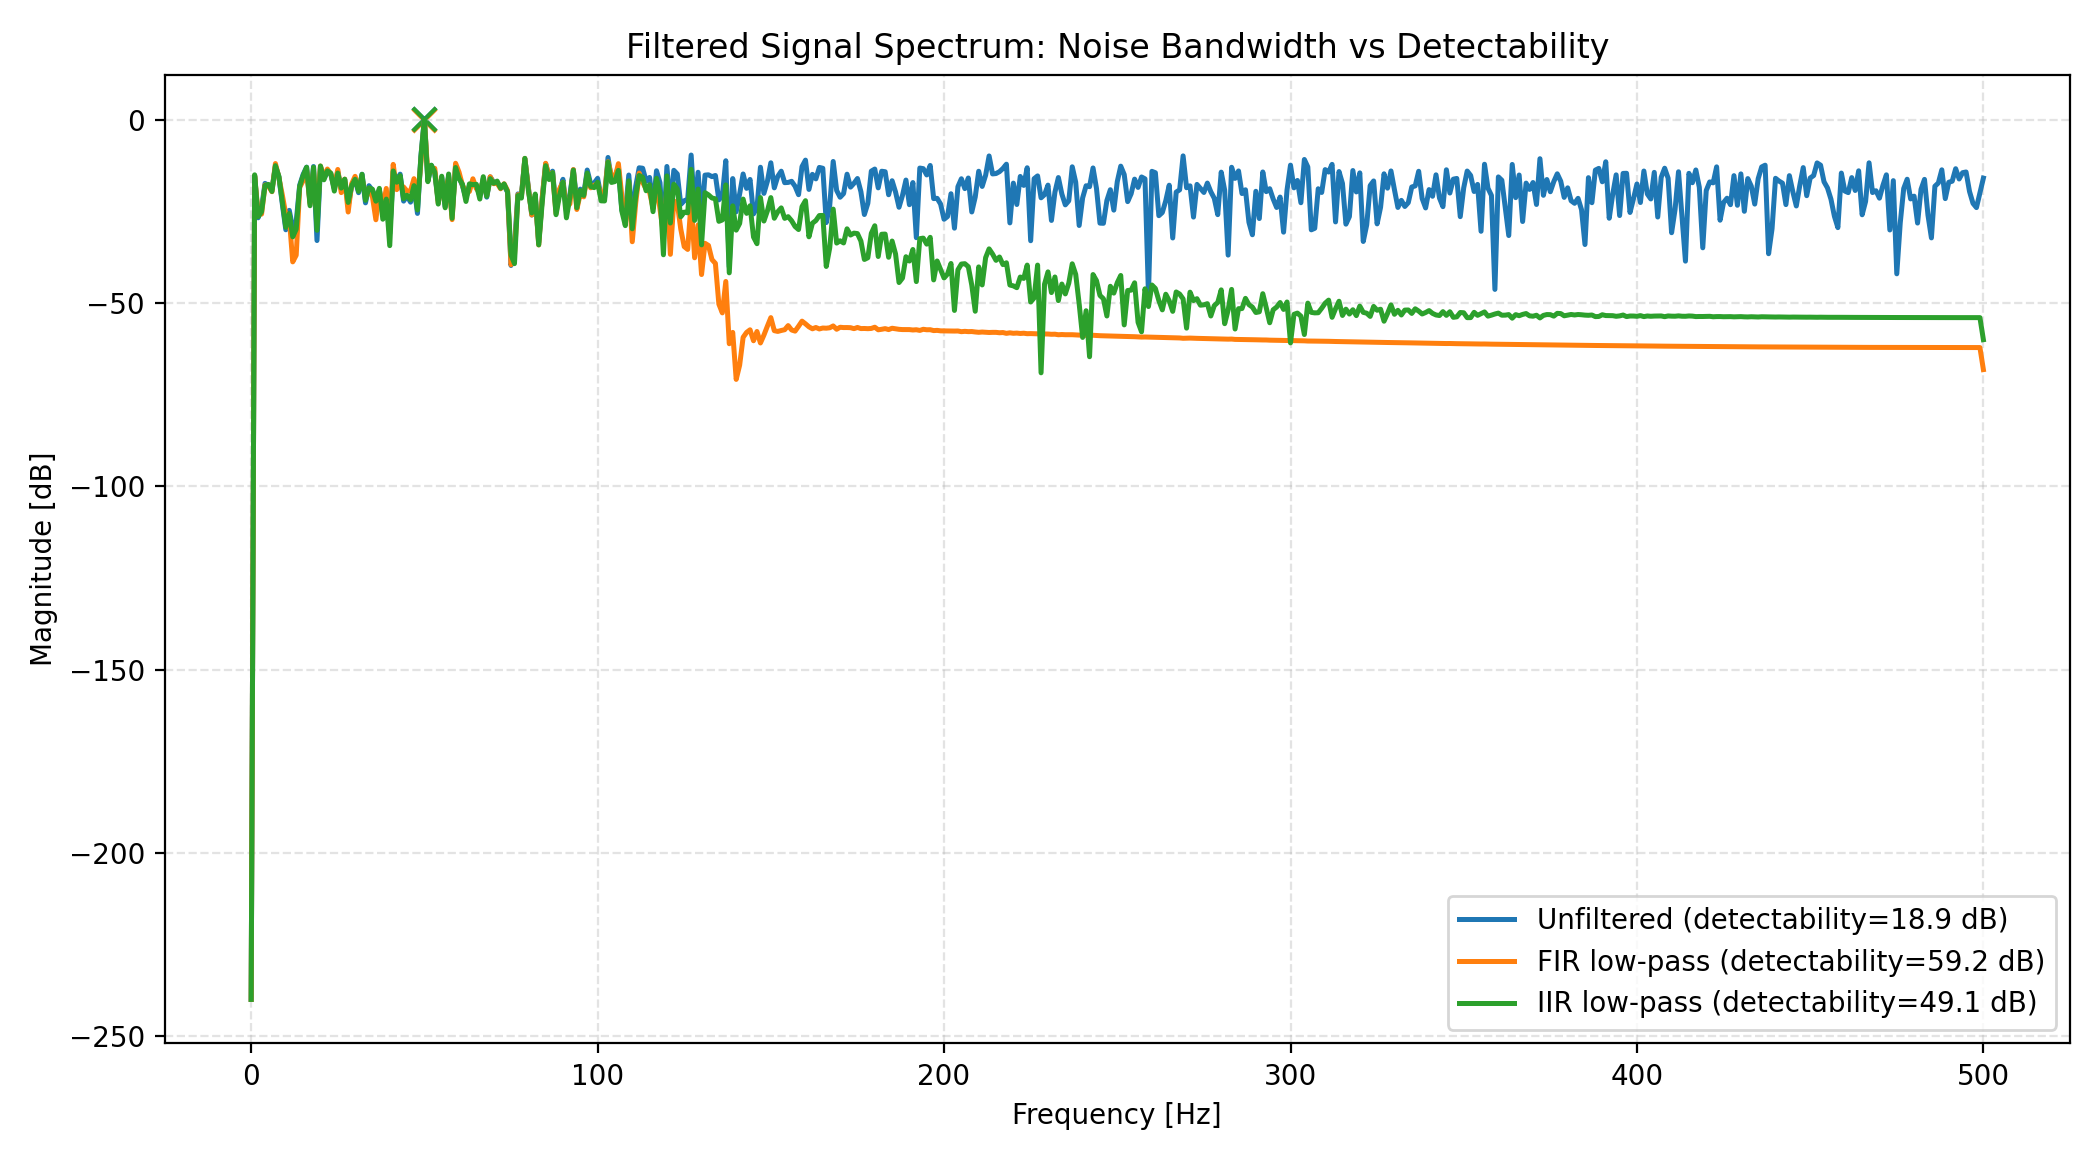

[ARTIFACT] figures/generated_plots/02_filter_detectability_summary.png


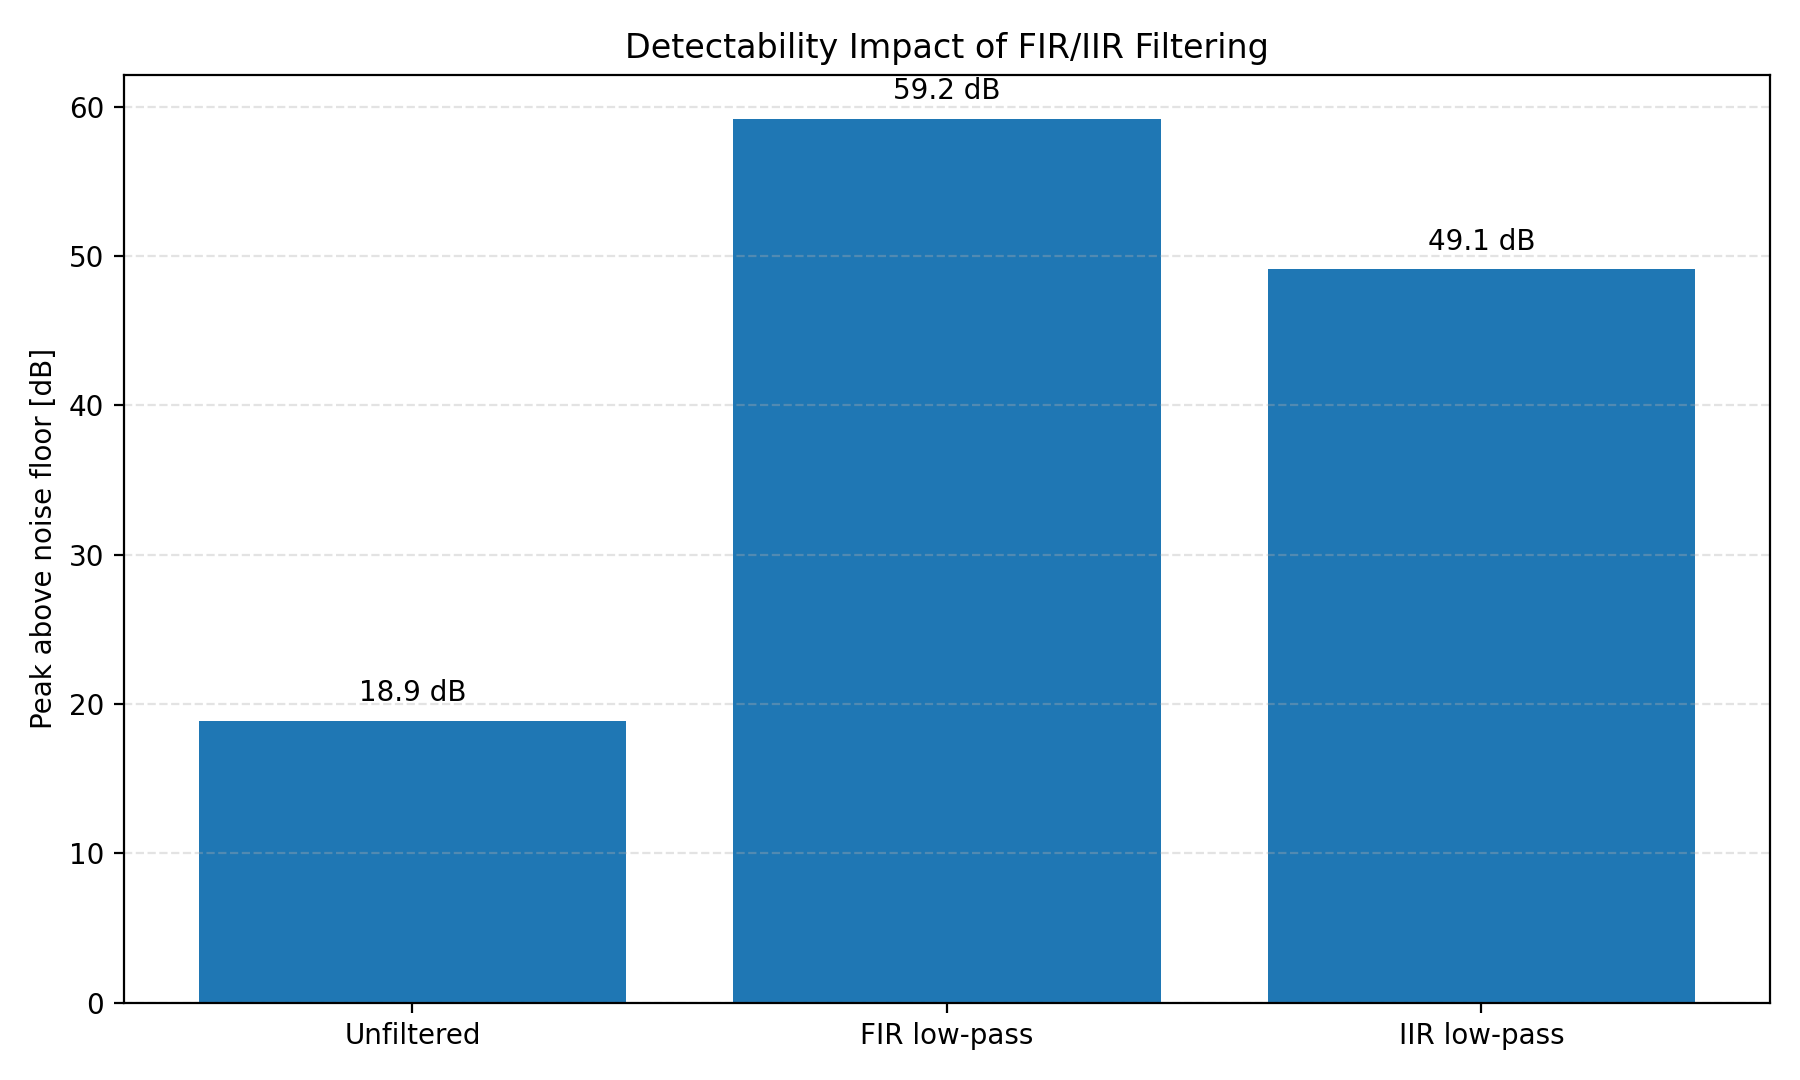

In [4]:
run_stage("02_fir_iir_filters.py")

show_artifact("figures/generated_plots/02_filter_response_fir_vs_iir.png")
show_artifact("figures/generated_plots/02_filtered_signal_spectrum.png")
show_artifact("figures/generated_plots/02_filter_detectability_summary.png")

## 4. Stage 03 — Windowing, leakage, coherent gain, and ENBW

Stage 03 shows why windowing is not cosmetic.

Windows reduce leakage but modify coherent gain and equivalent noise bandwidth. In radar/Doppler processing, that trade-off matters because it affects both amplitude interpretation and noise behavior.

[RUN] /Users/jpsmac/tmp/radar_clone_test/.venv/bin/python /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline/scripts/03_windowing_leakage.py

[OK] Stage 03 windowing/leakage summary
rectangular  | Peak=   -2.91 dB @    51.00 Hz | Floor=  -23.51 dB | Detectability=   20.60 dB | CG=1.000 | ENBW= 1.00
hann         | Peak=   -0.00 dB @    51.00 Hz | Floor=  -21.66 dB | Detectability=   21.66 dB | CG=0.500 | ENBW= 1.50
hamming      | Peak=   -0.38 dB @    51.00 Hz | Floor=  -22.10 dB | Detectability=   21.72 dB | CG=0.540 | ENBW= 1.36
blackman     | Peak=    0.36 dB @    51.00 Hz | Floor=  -20.96 dB | Detectability=   21.31 dB | CG=0.420 | ENBW= 1.73

[OK] Generated Stage 03 artifacts:
  figures/generated_plots/03_window_leakage_comparison.png
  figures/generated_plots/03_detectability_window_tradeoff.png
  figures/generated_plots/03_window_metrics_summary.png

[ARTIFACT] figures/generated_plots/03_window_leakage_comparison.png


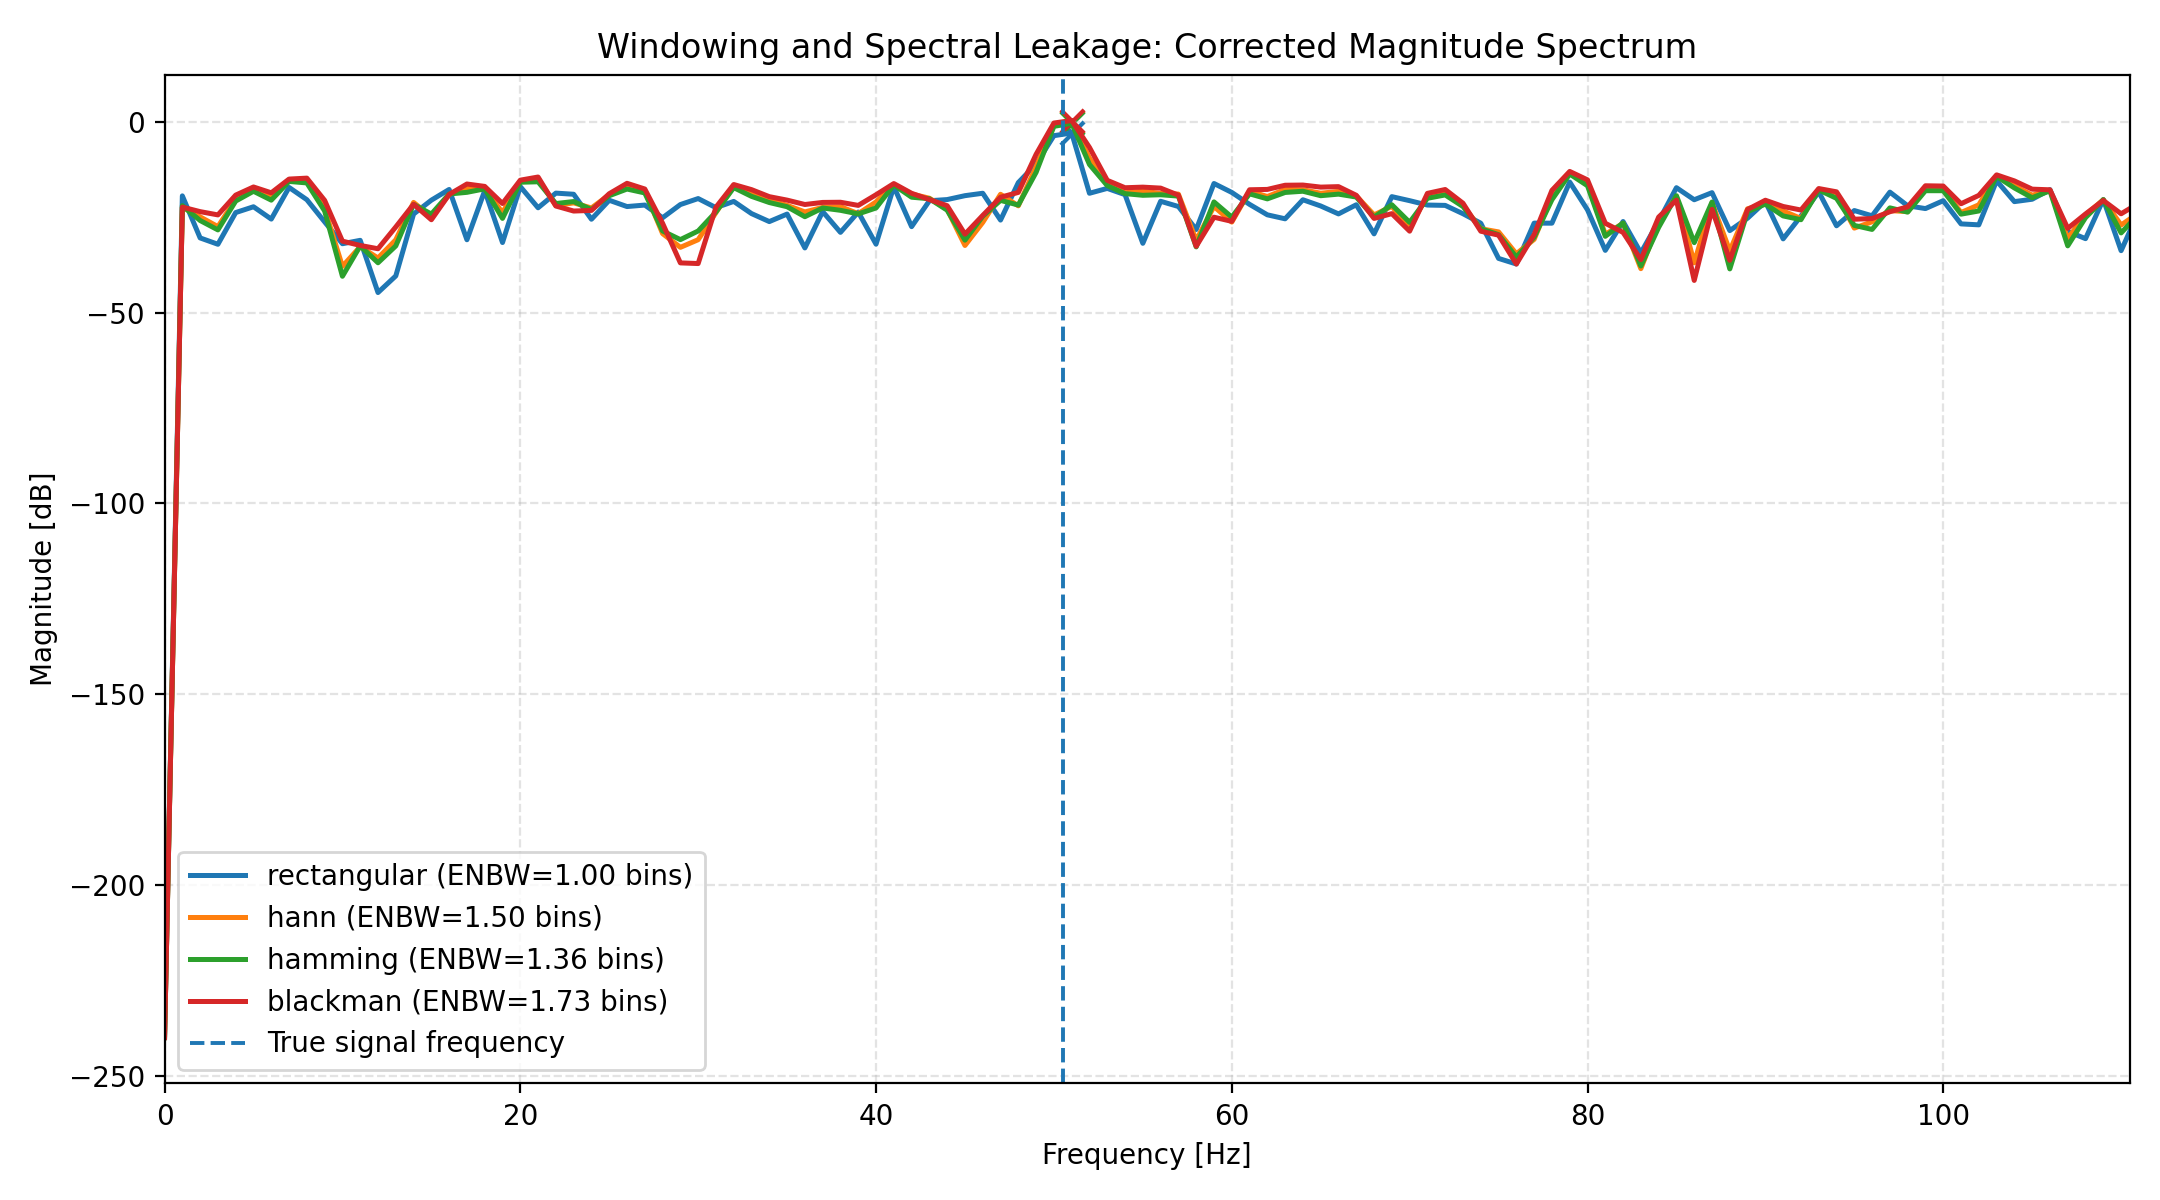

[ARTIFACT] figures/generated_plots/03_window_metrics_summary.png


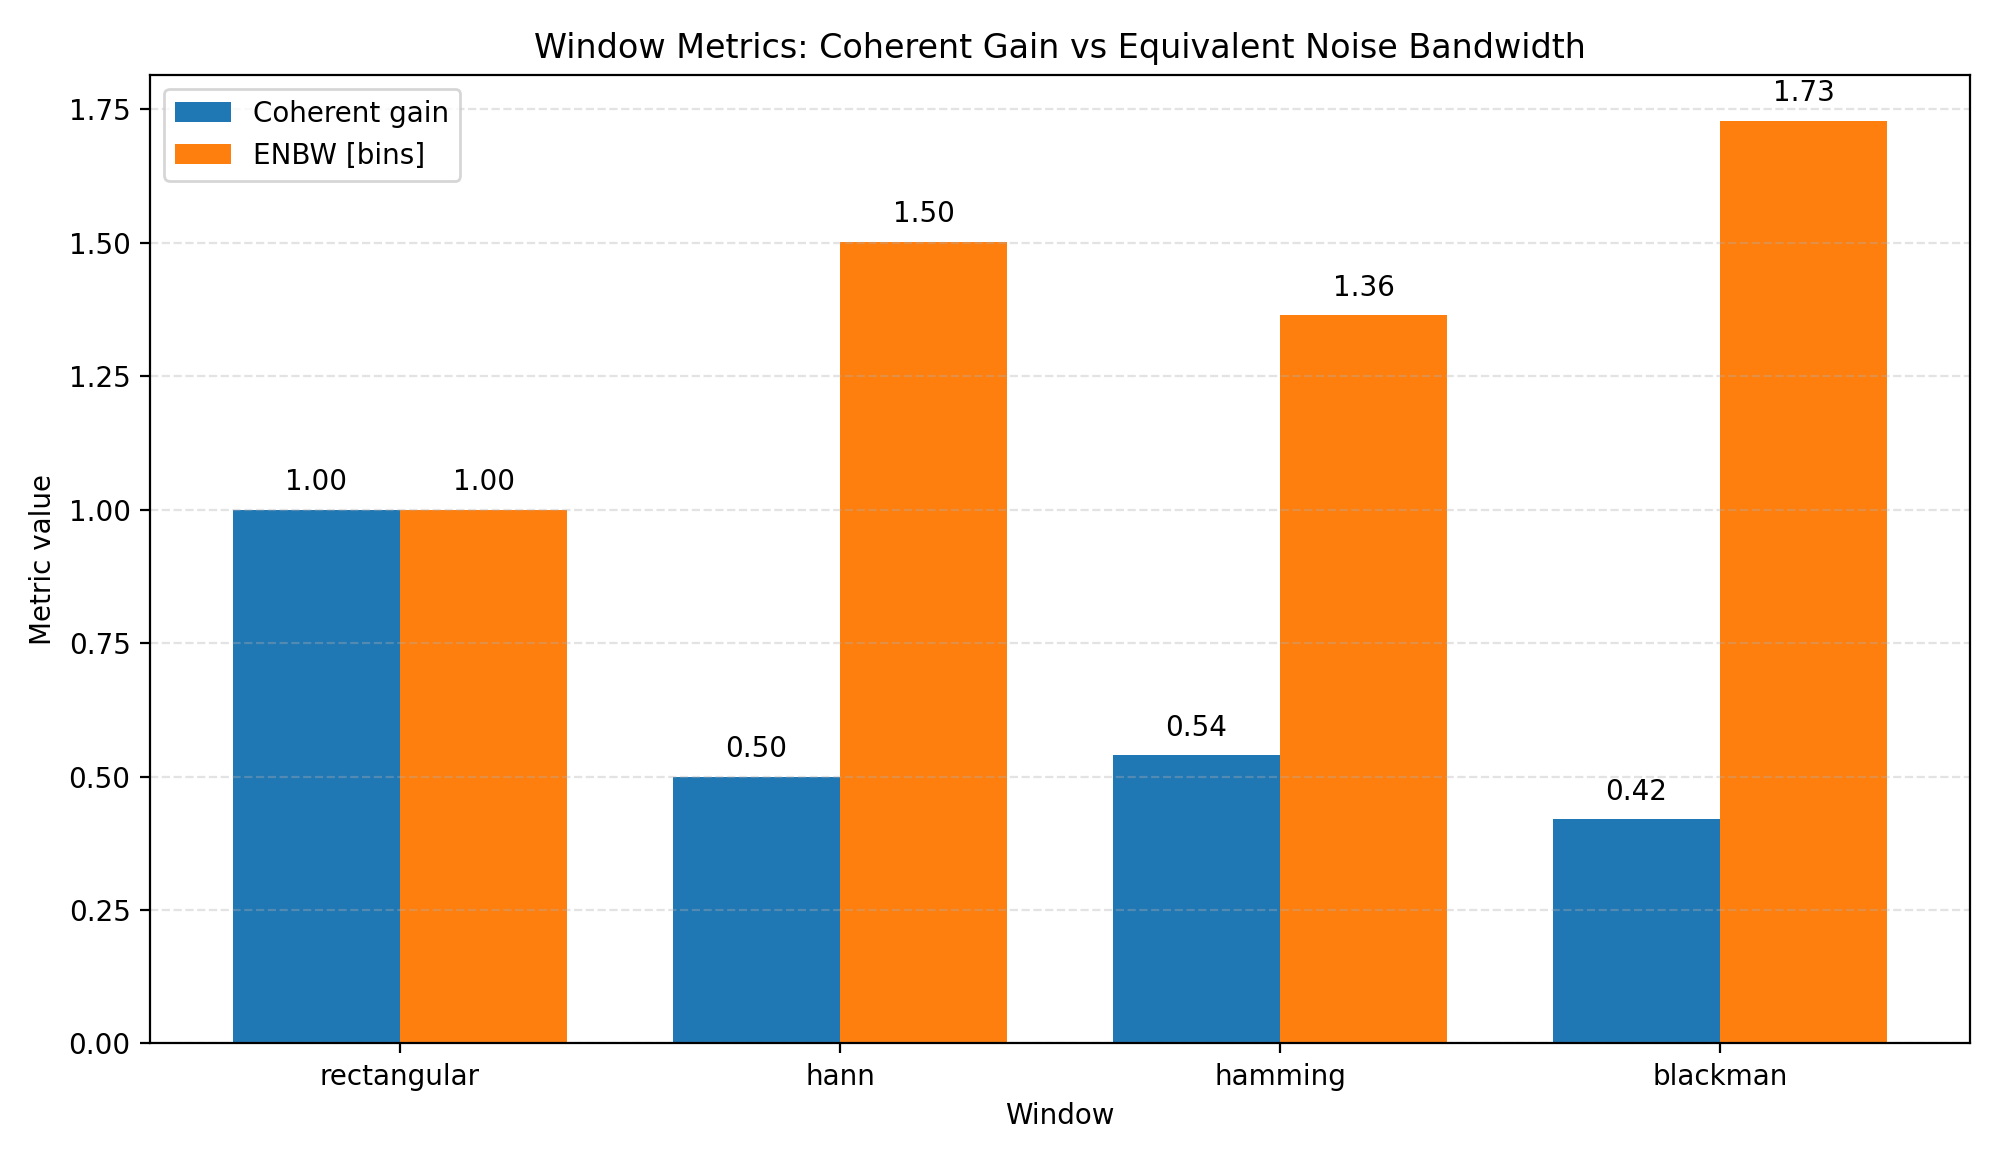

[ARTIFACT] figures/generated_plots/03_detectability_window_tradeoff.png


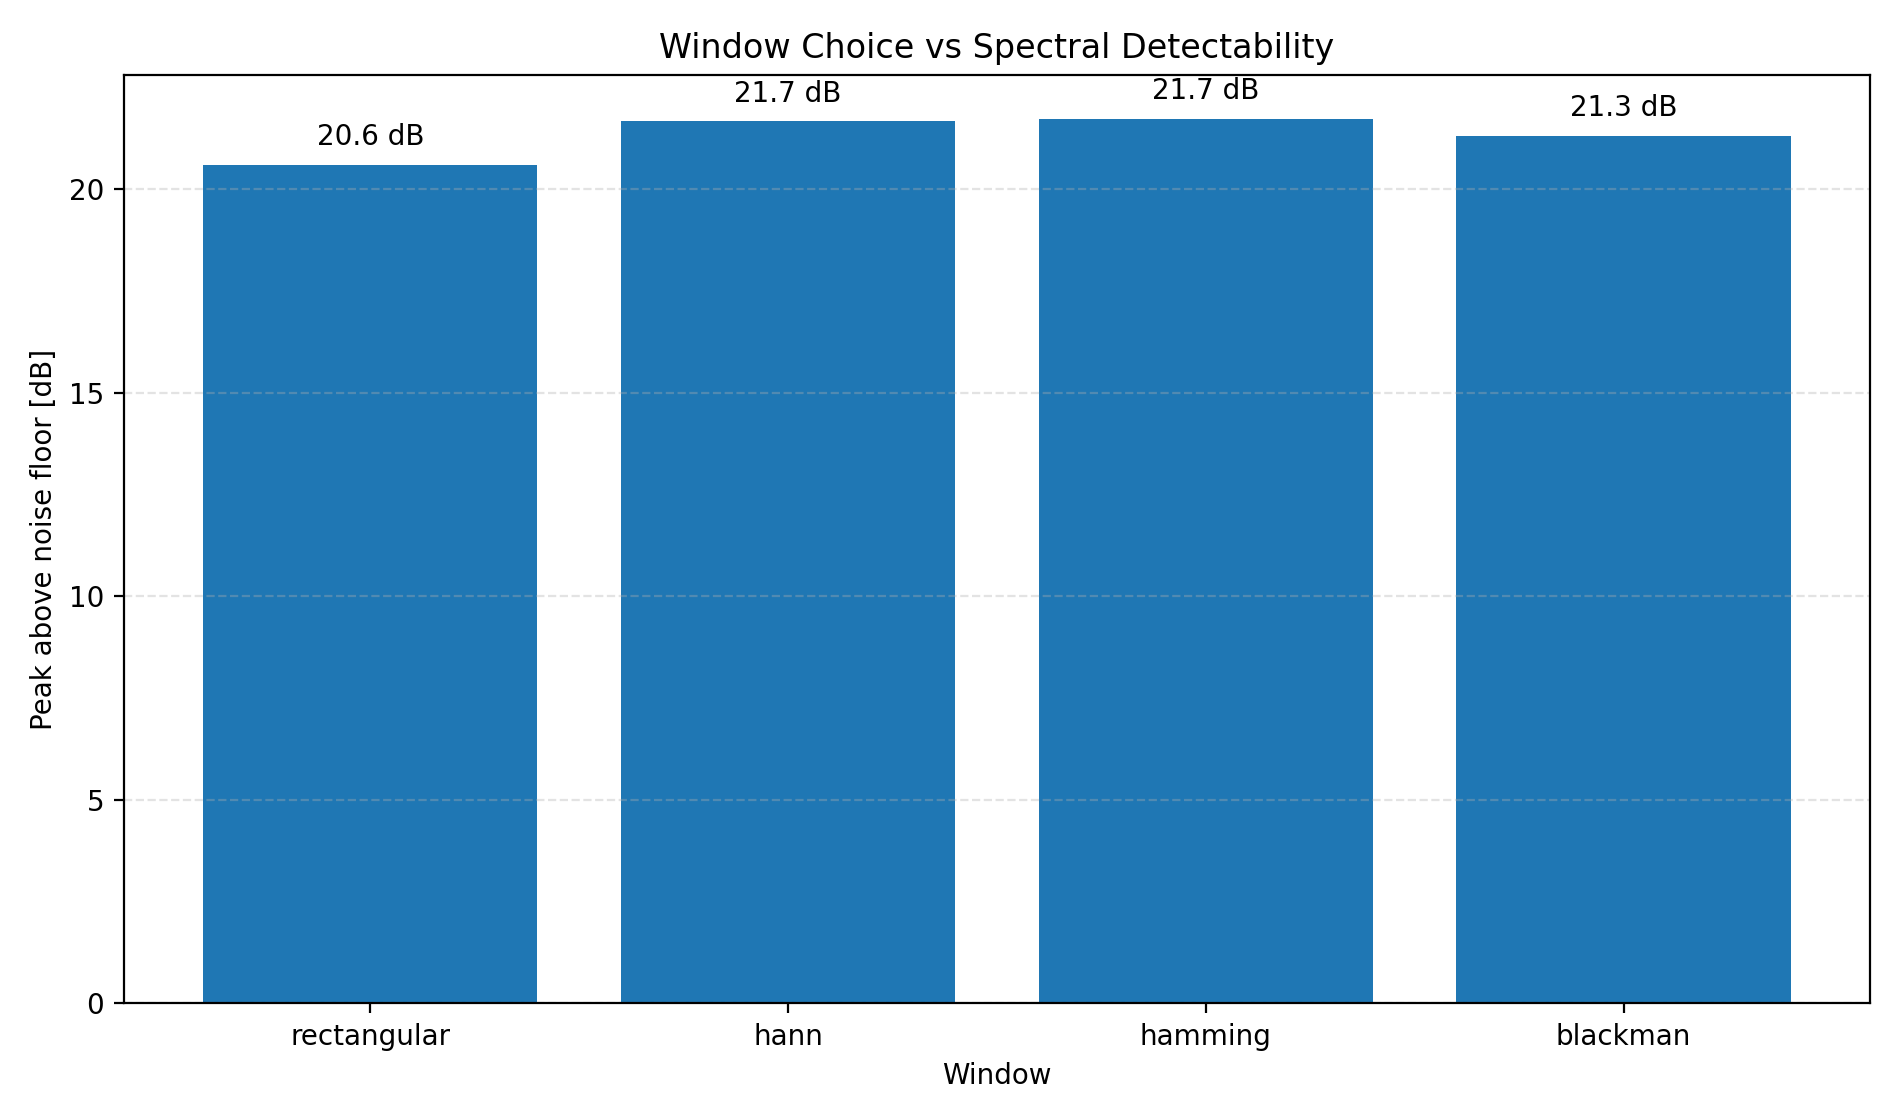

In [5]:
run_stage("03_windowing_leakage.py")

show_artifact("figures/generated_plots/03_window_leakage_comparison.png")
show_artifact("figures/generated_plots/03_window_metrics_summary.png")
show_artifact("figures/generated_plots/03_detectability_window_tradeoff.png")

## 5. Stage 04 — Doppler-like peak detection and empirical Pd/Pfa

Stage 04 moves from visibility to detection.

A peak can be visible, but the detector still needs a threshold. This stage estimates a threshold from noise-only trials, then measures empirical probability of detection and false-alarm behavior.

[RUN] /Users/jpsmac/tmp/radar_clone_test/.venv/bin/python /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline/scripts/04_detection_doppler.py

[OK] Stage 04 empirical detection summary
SNR= -35.00 dB | Pd= 0.055 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=  -17.27 dB | Mean H0 peak=  -17.22 dB
SNR= -30.00 dB | Pd= 0.060 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=  -17.17 dB | Mean H0 peak=  -17.22 dB
SNR= -25.00 dB | Pd= 0.083 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=  -16.96 dB | Mean H0 peak=  -17.22 dB
SNR= -20.00 dB | Pd= 0.293 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=  -15.73 dB | Mean H0 peak=  -17.22 dB
SNR= -15.00 dB | Pd= 0.845 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=  -12.54 dB | Mean H0 peak=  -17.22 dB
SNR= -10.00 dB | Pd= 1.000 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=   -7.96 dB | Mean H0 peak=  -17.22 dB
SNR=  -5.00 dB | Pd= 1.000 | Pfa= 0.050 | Threshold=  -14.54 dB | Mean H1 peak=   -3.21 dB | Mean H0 peak=  -1

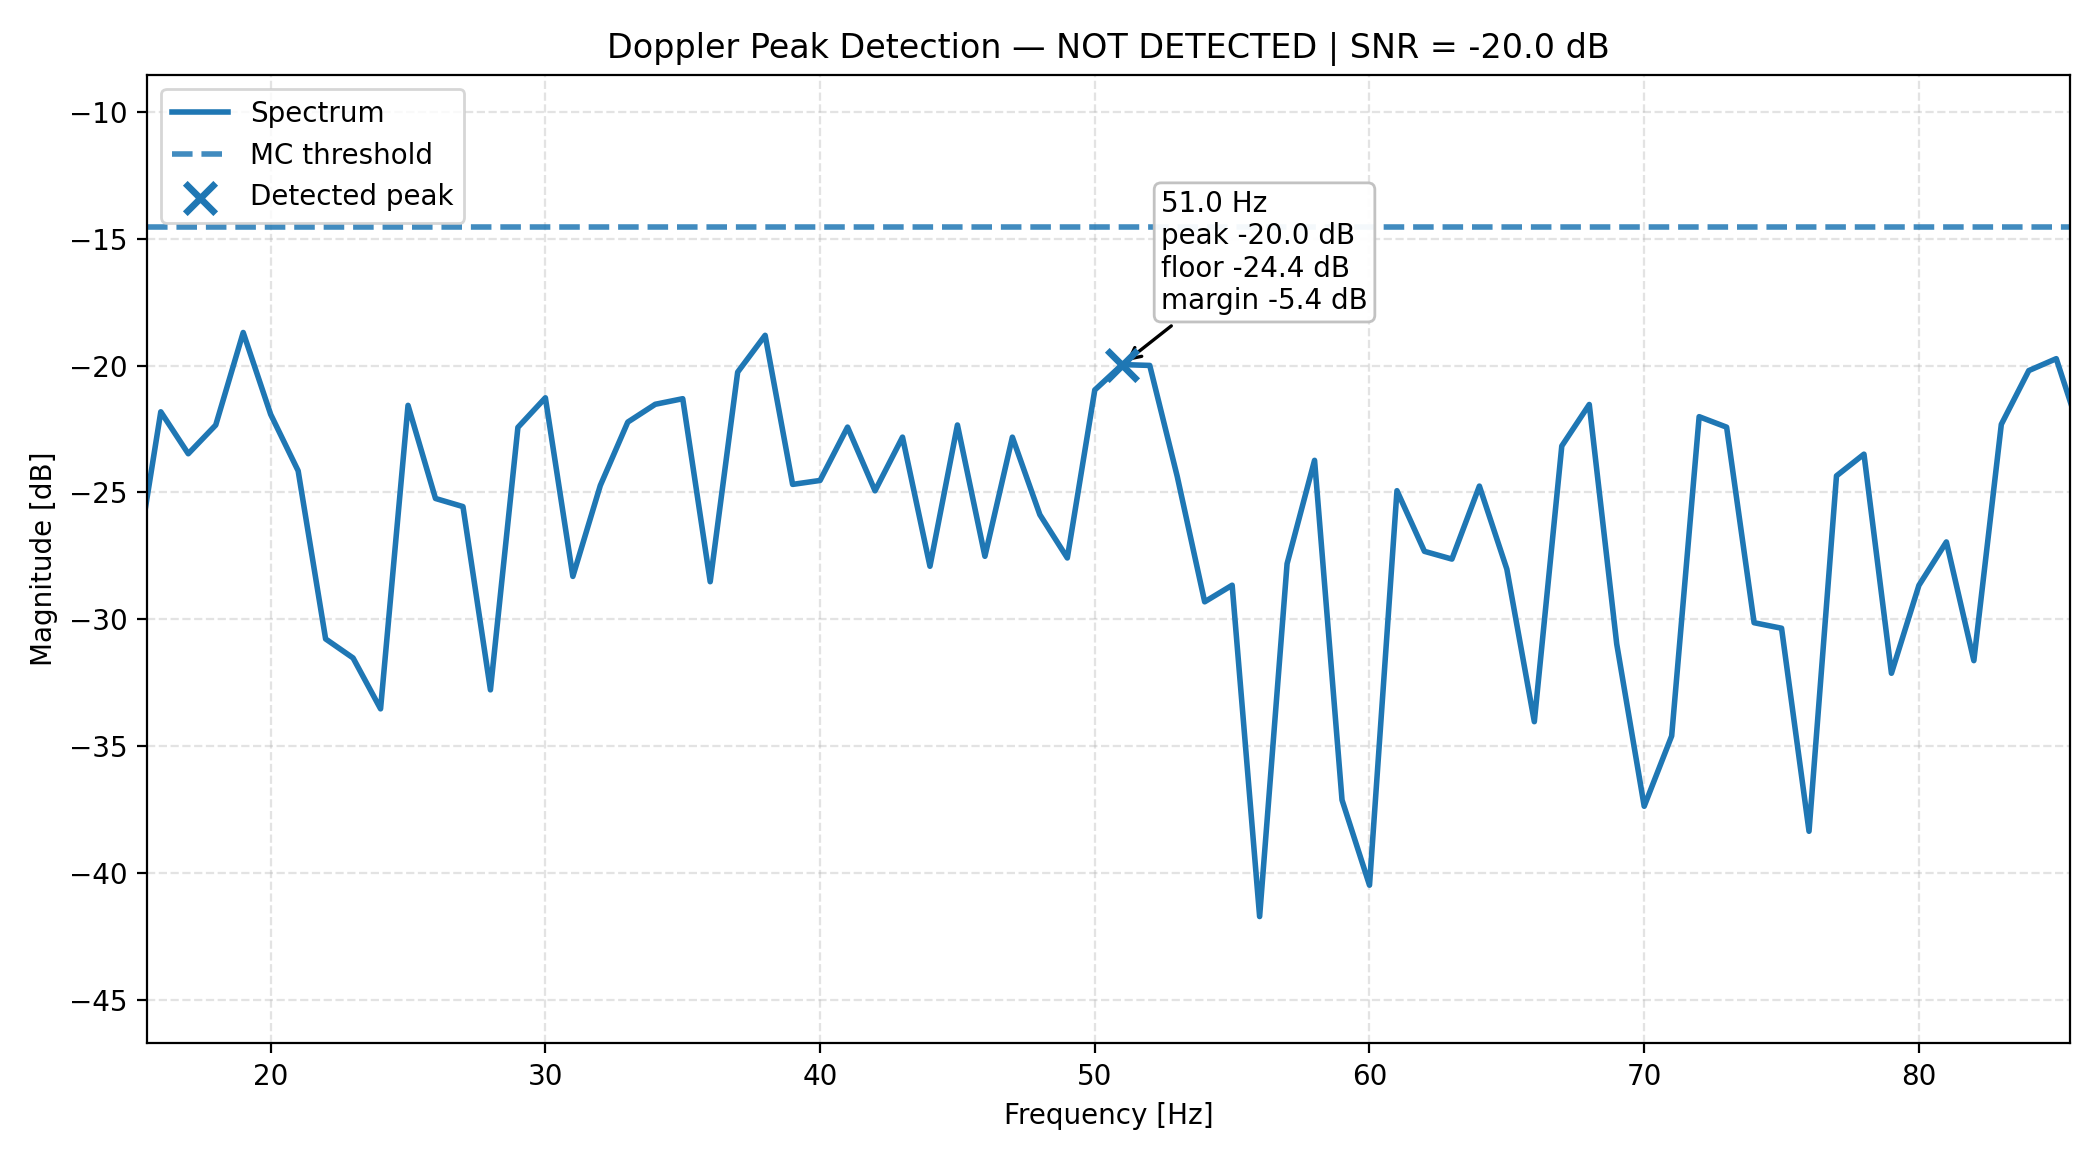

[ARTIFACT] figures/generated_plots/04_pd_pfa_basic.png


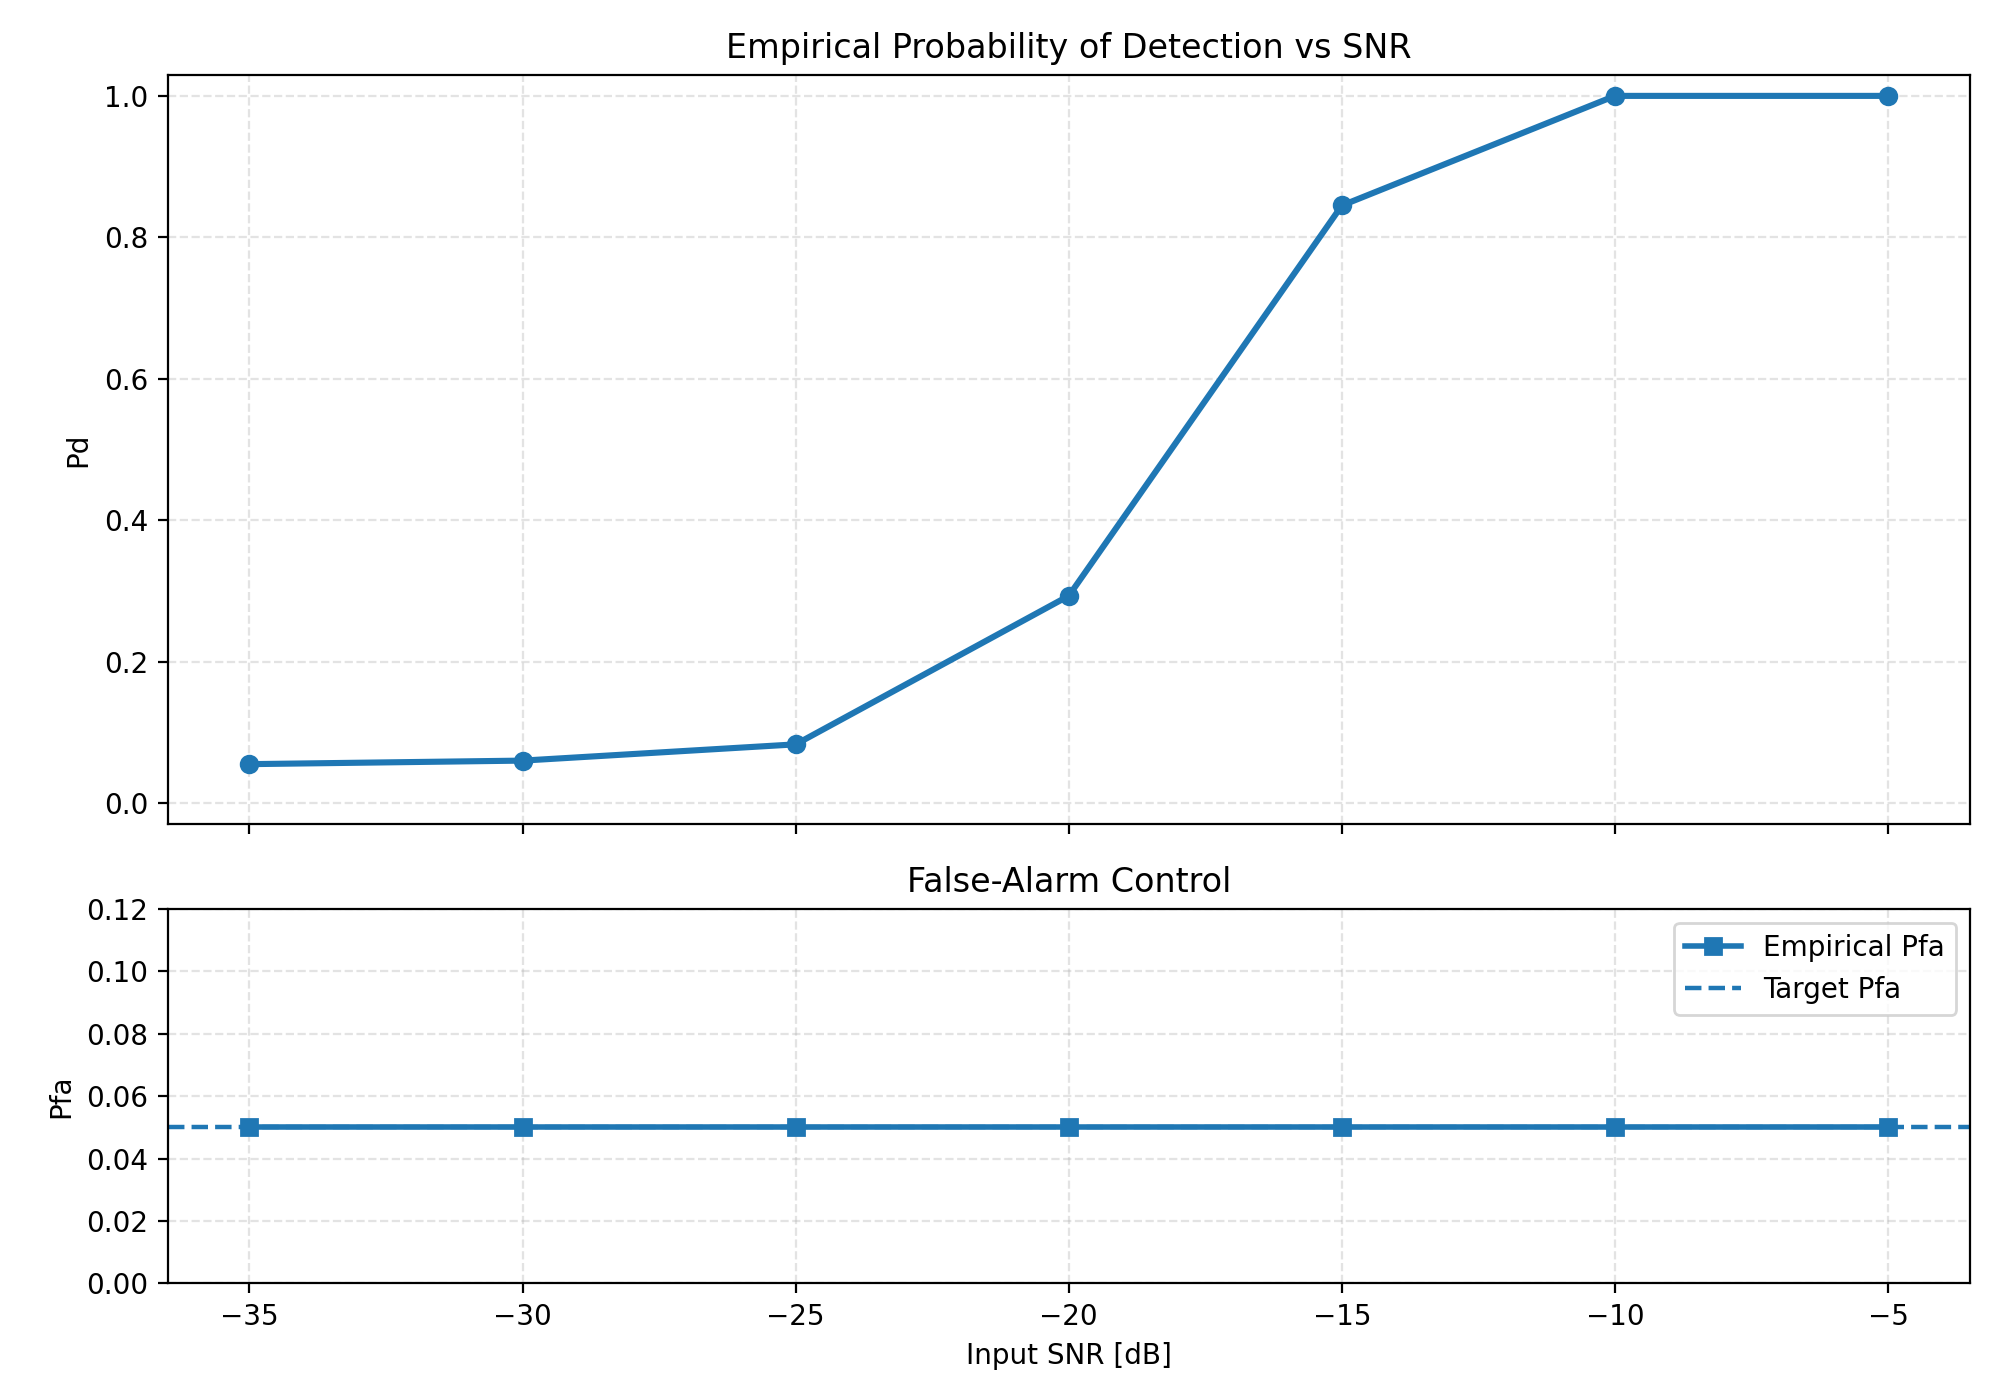

In [6]:
run_stage("04_detection_doppler.py")

show_artifact("figures/generated_plots/04_doppler_peak_detection.png")
show_artifact("figures/generated_plots/04_pd_pfa_basic.png")

## 6. Stage 05 — System-level DSP trade-offs

Stage 05 is the engineering summary.

It compares processing chains using:

- fixed-threshold detection
- CA-CFAR detection
- empirical Pd vs SNR
- empirical Pfa control
- interpolated SNR required to reach target Pd

This is the part of the repository that connects individual DSP choices to system-level detection behavior.

[RUN] /Users/jpsmac/tmp/radar_clone_test/.venv/bin/python /Users/jpsmac/Documents/RADAR/radar-dsp-pipeline/scripts/05_system_tradeoffs.py

[OK] Stage 05 system trade-off summary
No filter + Rectangular     | fixed_threshold | Pfa= 0.050 | Max Pd=0.993 | SNR@Pd≥0.90: -10.7 dB
No filter + Rectangular     | ca_cfar         | Pfa= 0.060 | Max Pd=0.990 | SNR@Pd≥0.90: -10.5 dB
No filter + Hann            | fixed_threshold | Pfa= 0.050 | Max Pd=0.996 | SNR@Pd≥0.90: -10.4 dB
No filter + Hann            | ca_cfar         | Pfa= 0.048 | Max Pd=0.987 | SNR@Pd≥0.90: -10.2 dB
FIR low-pass + Hann         | fixed_threshold | Pfa= 0.050 | Max Pd=0.993 | SNR@Pd≥0.90: -10.4 dB
FIR low-pass + Hann         | ca_cfar         | Pfa= 0.062 | Max Pd=0.988 | SNR@Pd≥0.90: -9.9 dB
IIR low-pass + Hann         | fixed_threshold | Pfa= 0.050 | Max Pd=0.993 | SNR@Pd≥0.90: -10.3 dB
IIR low-pass + Hann         | ca_cfar         | Pfa= 0.058 | Max Pd=0.989 | SNR@Pd≥0.90: -10.5 dB
FIR low-pass + Blackman     | fixed_thr

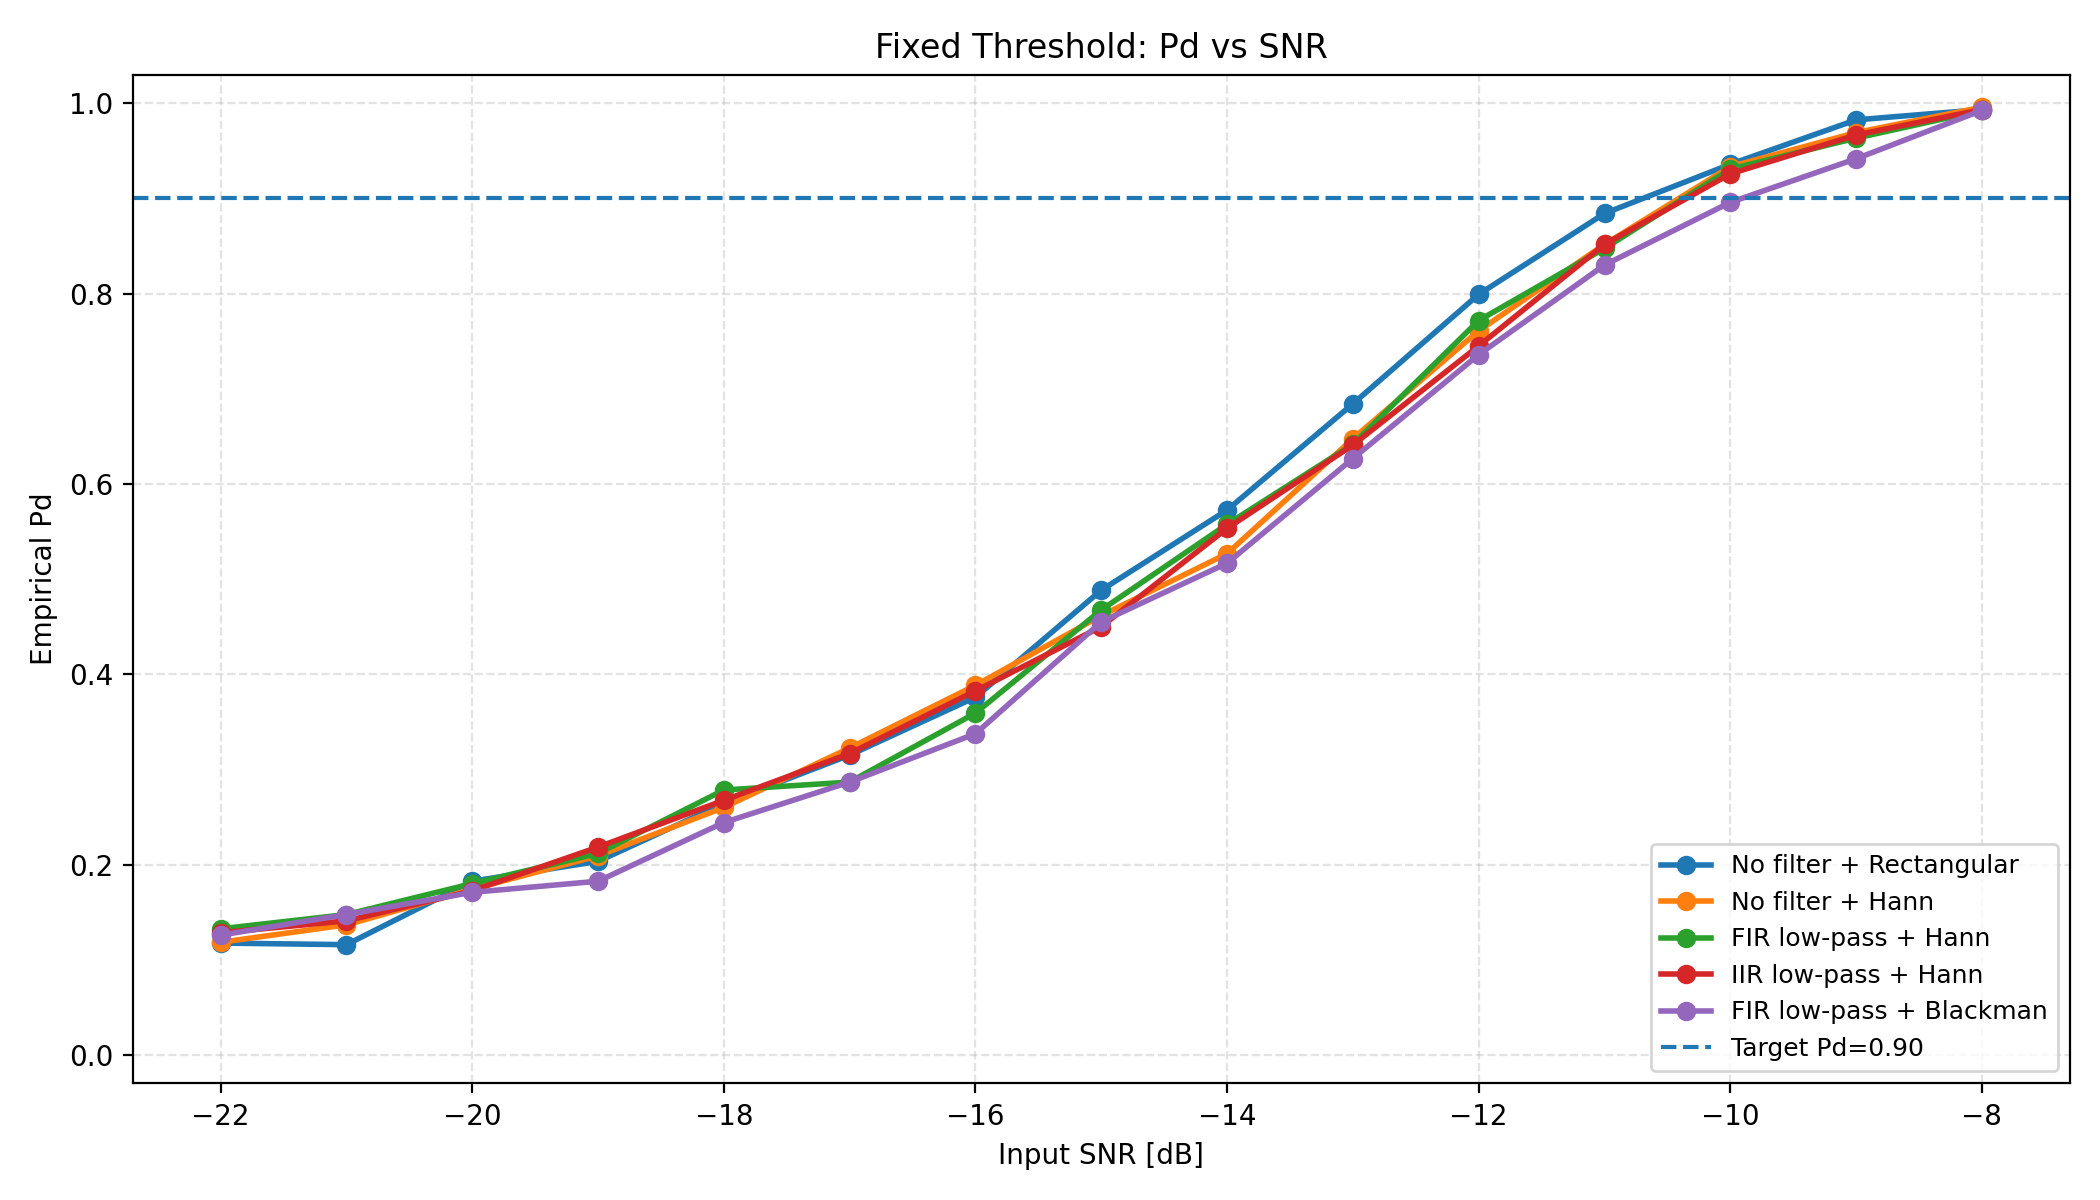

[ARTIFACT] figures/generated_plots/05_ca_cfar_pd_vs_snr.png


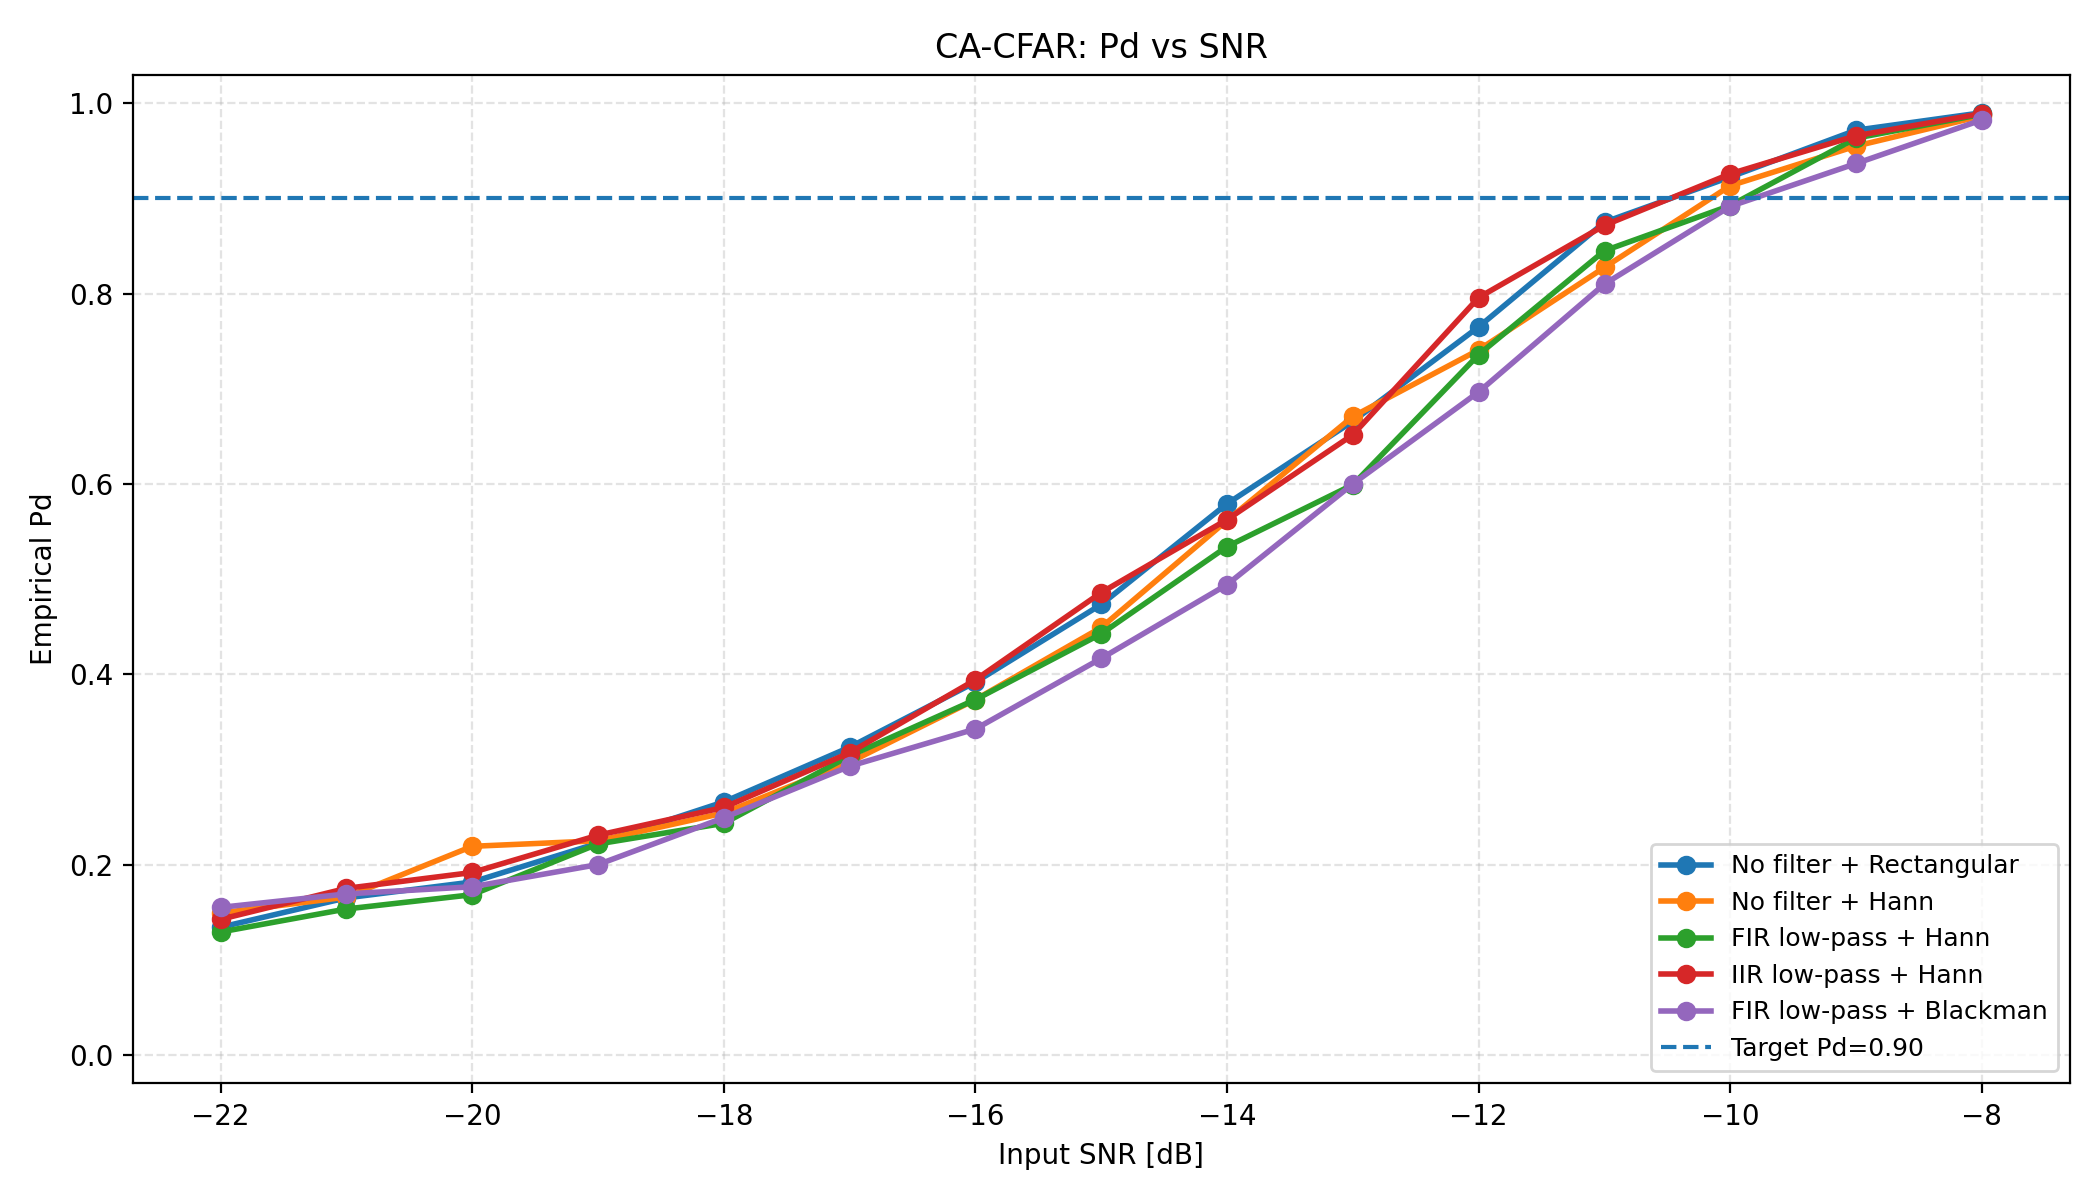

[ARTIFACT] figures/generated_plots/05_false_alarm_control.png


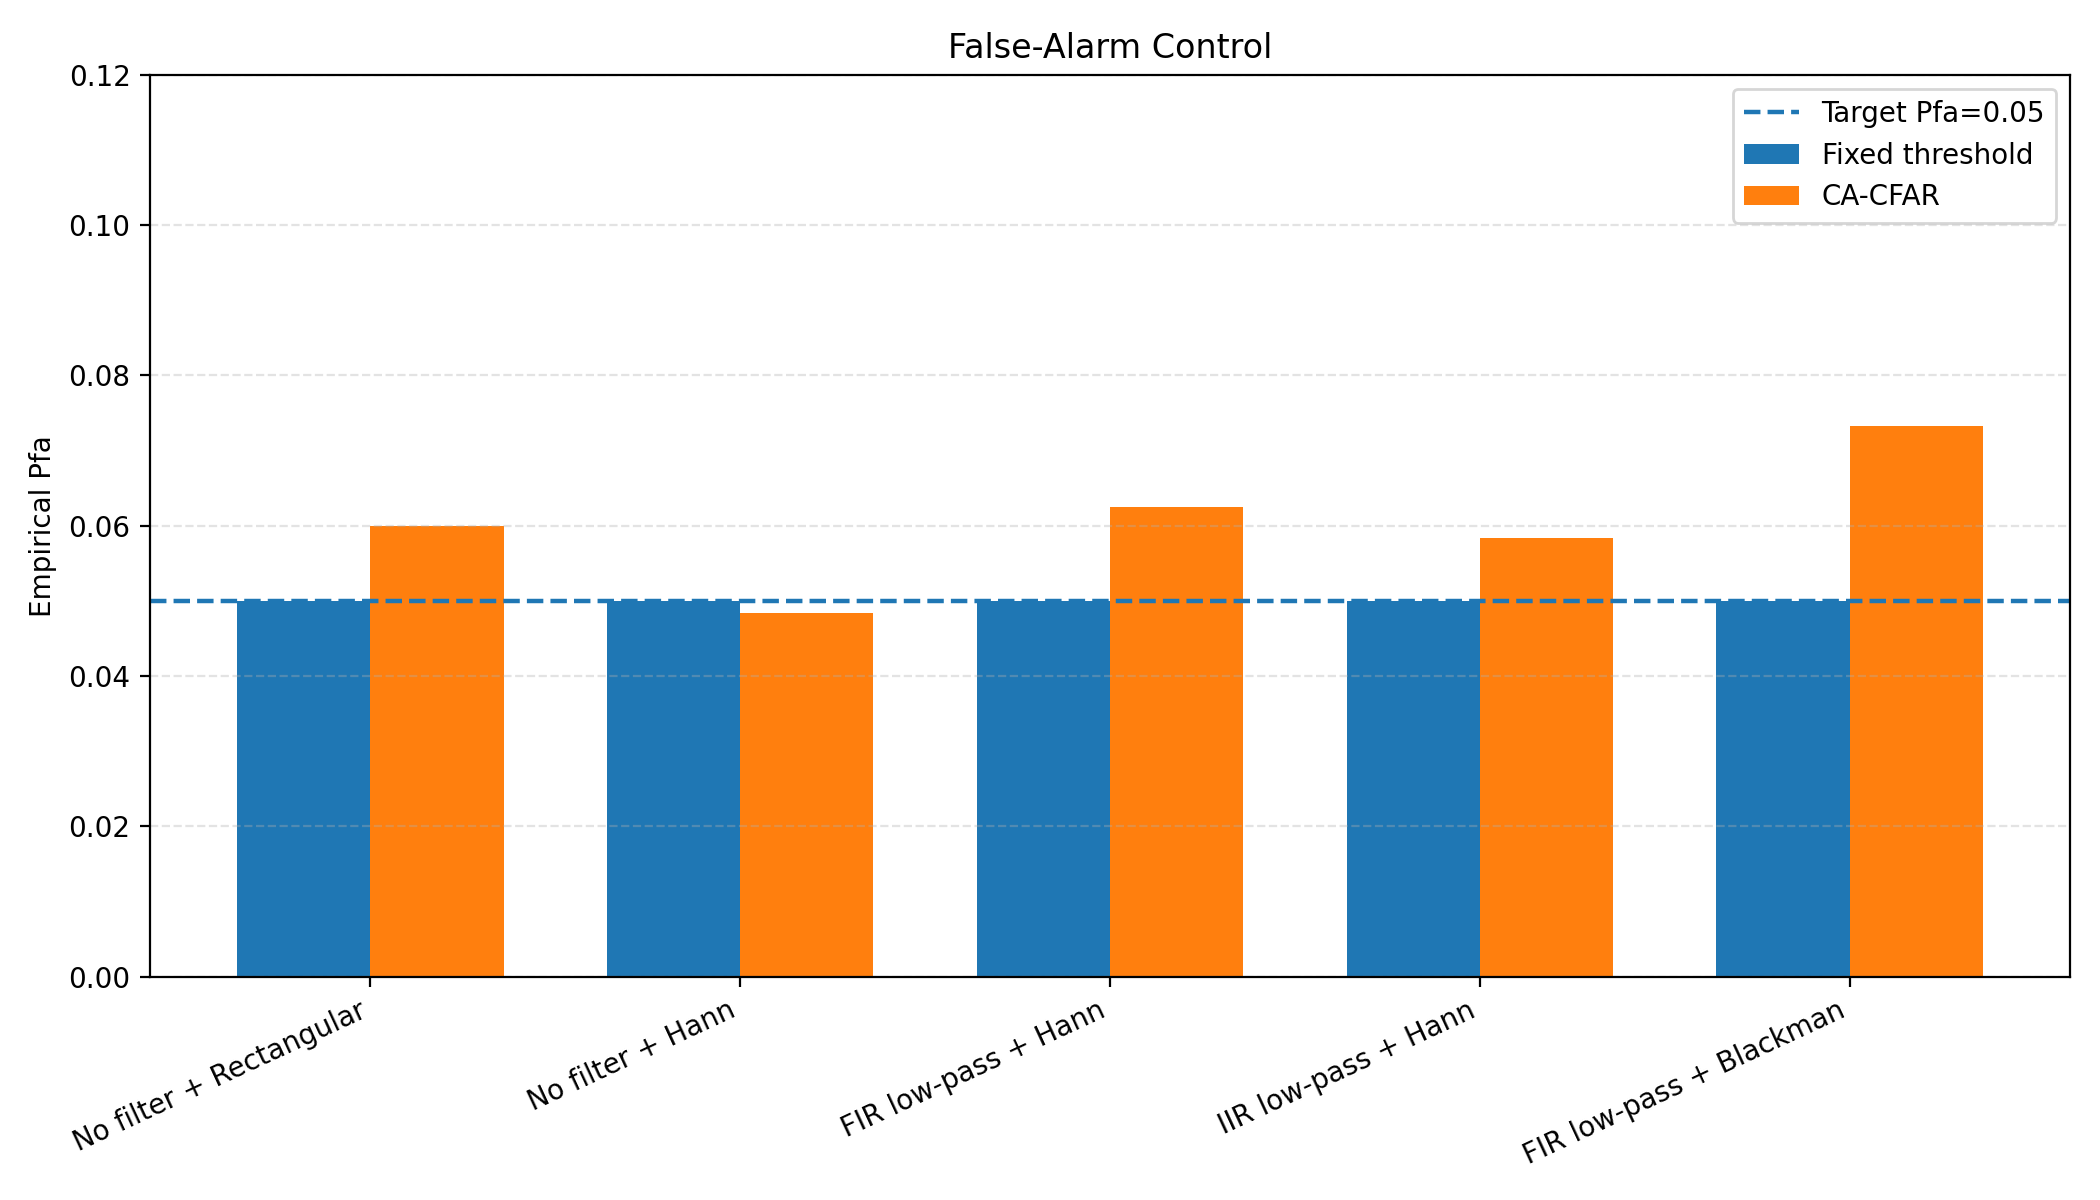

[ARTIFACT] figures/generated_plots/05_snr_requirement_summary.png


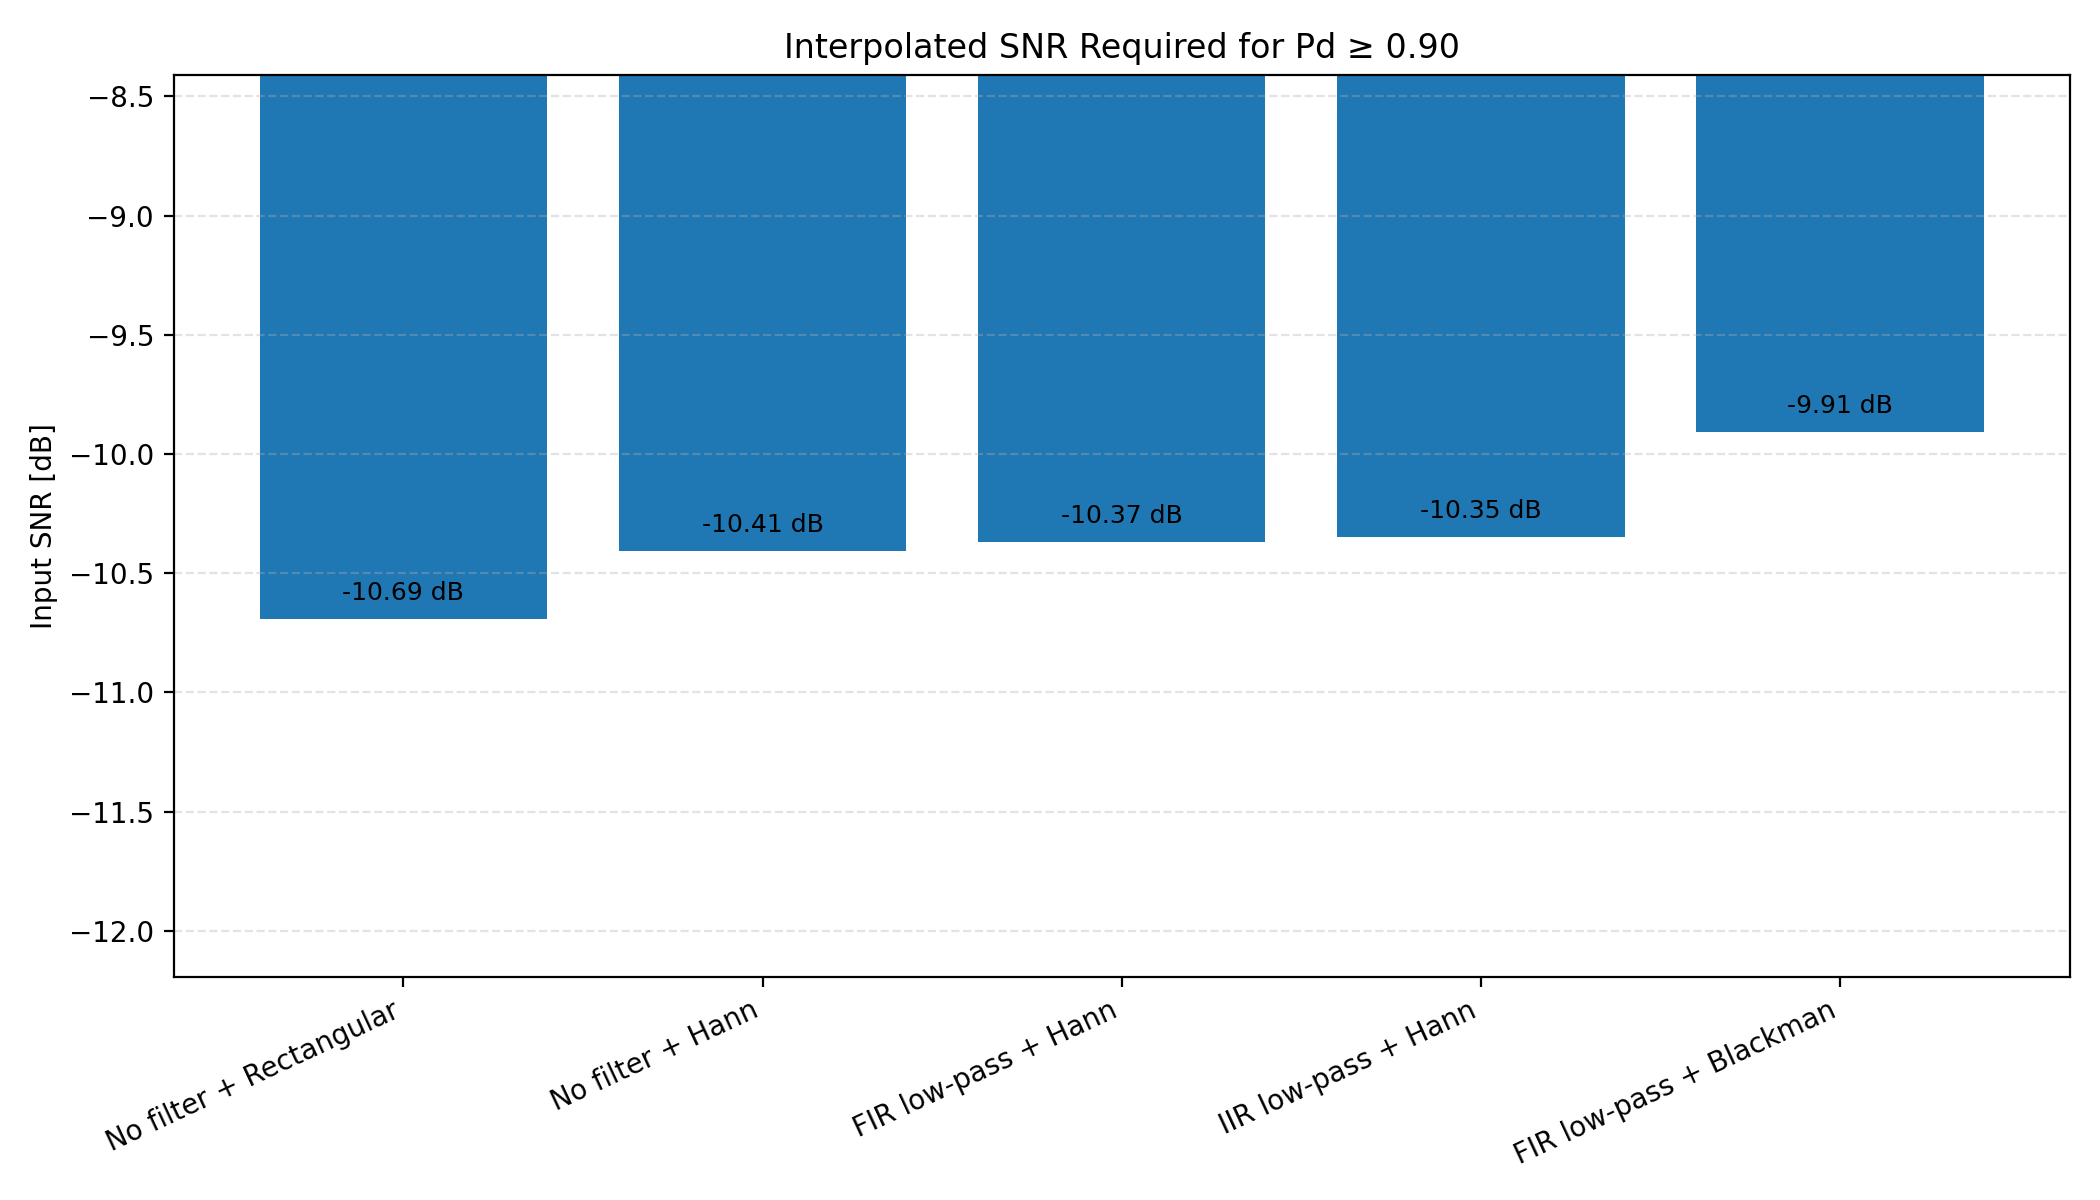

In [7]:
run_stage("05_system_tradeoffs.py")

show_artifact("figures/generated_plots/05_fixed_threshold_pd_vs_snr.png")
show_artifact("figures/generated_plots/05_ca_cfar_pd_vs_snr.png")
show_artifact("figures/generated_plots/05_false_alarm_control.png")
show_artifact("figures/generated_plots/05_snr_requirement_summary.png")

## 7. Stage 05 numerical summary

The CSV output is the compact engineering summary.  
It is useful for reviewing detector behavior without inspecting every plot.

In [8]:
df_metrics = read_csv_artifact("figures/generated_plots/05_pipeline_metrics.csv")
display(df_metrics)

,chain_name,detector,filter_type,window_name,cost_units,empirical_pfa,threshold_db,mean_noise_stat_db,snr_for_target_pd_db,max_pd
0,No filter + Rectangular,fixed_threshold,none,rectangular,1.0,0.050000,-13.112440,-20.330181,-10.693548,0.993333
1,No filter + Rectangular,ca_cfar,none,rectangular,1.7,0.060000,-13.244369,-20.339817,-10.473684,0.990000
2,No filter + Hann,fixed_threshold,none,hann,1.2,0.050000,-11.470846,-18.491334,-10.408163,0.995833
3,No filter + Hann,ca_cfar,none,hann,1.9,0.048333,-11.443594,-19.149321,-10.155340,0.986667
4,FIR low-pass + Hann,fixed_threshold,fir_lowpass,hann,4.0,0.050000,-11.630349,-18.632831,-10.370000,0.992500
5,FIR low-pass + Hann,ca_cfar,fir_lowpass,hann,4.7,0.062500,-11.632777,-18.941536,-9.894118,0.988333
6,IIR low-pass + Hann,fixed_threshold,iir_lowpass,hann,2.0,0.050000,-11.447589,-18.602596,-10.348315,0.993333
7,IIR low-pass + Hann,ca_cfar,iir_lowpass,hann,2.7,0.058333,-11.690680,-18.625134,-10.476923,0.989167
8,FIR low-pass + Blackman,fixed_threshold,fir_lowpass,blackman,4.3,0.050000,-11.010476,-18.450714,-9.909091,0.992500
9,FIR low-pass + Blackman,ca_cfar,fir_lowpass,blackman,5.0,0.073333,-10.994817,-17.972483,-9.814815,0.982500


## 8. Interpretation

The pipeline demonstrates a progression from signal representation to system-level detection trade-offs.

Key conclusions from the default run:

- FFT analysis can expose a weak narrowband component that is not obvious in the time domain.
- Detectability is not the same as detection; thresholding changes the problem.
- Filters and windows alter the signal/noise relationship in measurable ways.
- Fixed thresholds can be tuned directly from Monte Carlo H0 trials.
- CA-CFAR must be evaluated in linear power and at a defined cell under test.
- SNR required to reach a target Pd is a practical summary metric for comparing DSP choices.

This repository is therefore not a collection of plots. It is a reproducible DSP analysis pipeline with explicit assumptions, generated artifacts, and measurable detection consequences.

## 9. Reproducibility checklist

A clean run should regenerate all expected artifacts under:

```text
figures/generated_plots/
```

Expected Stage 05 artifacts:

```text
05_fixed_threshold_pd_vs_snr.png
05_ca_cfar_pd_vs_snr.png
05_false_alarm_control.png
05_snr_requirement_summary.png
05_pipeline_metrics.csv
```